<a href="https://colab.research.google.com/github/StrawEater/PracticasPDI3erBimestre/blob/main/Laboratorios/Laboratorio_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from scipy.fft import fft, ifft, fft2, ifft2, fftshift, fftfreq
from skimage import data, color, transform
from skimage.draw import rectangle, line
from IPython.display import Image, display
import tempfile
import os
import unittest
from matplotlib.animation import FuncAnimation, PillowWriter

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11
plt.rcParams['image.cmap'] = 'gray'

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(42)

# ¿Qué es una señal?

> ### Definicion
> Una señal es una lista ordenada de números con un valor por cada posicion/indice:
> - **Tiempo** → audio, temperatura, ECG, cotización del dólar
> - **Espacio** → una fila de píxeles de una imagen
> - **Dos índices a la vez** → una imagen entera $f(x, y)$

Es decir,

$$\text{señal} = \text{vector} \in \mathbb{R}^N$$


## Ejemplos de señales

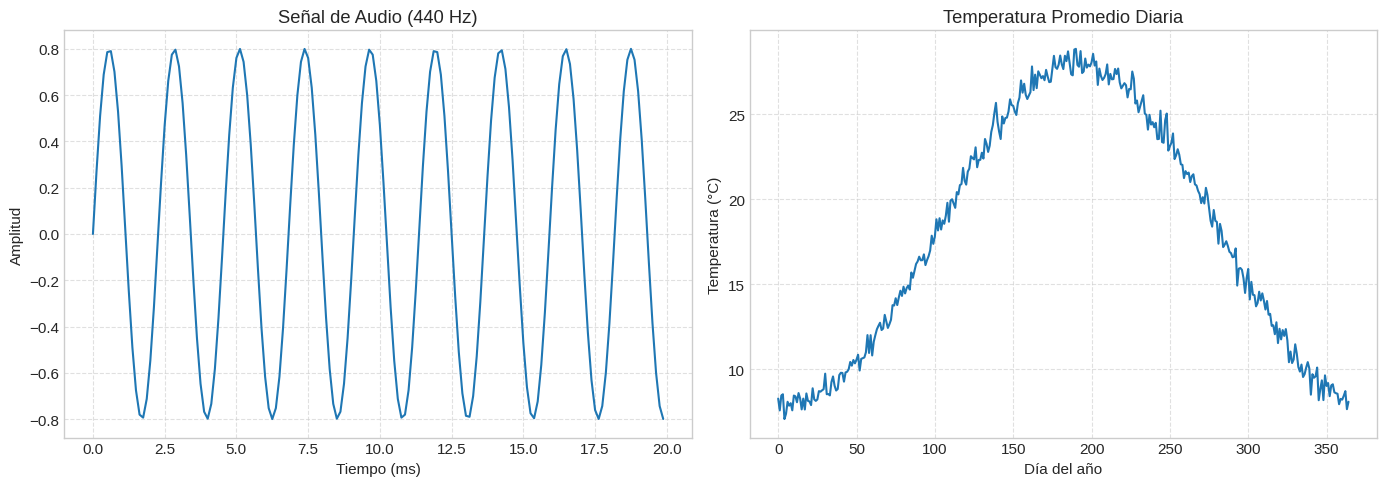

In [2]:
#Un audio a 440 Hz muestreado a 8000 muestras por segundo
frecuencia_de_muestreo = 8000
duracion = 0.02
tiempo_muestreado = np.arange(0, duracion, 1/frecuencia_de_muestreo) #10 milisegundos
audio = 0.8 * np.sin(2 * np.pi * 440 * tiempo_muestreado)

#Temperatura promedio diaria por año
dias = np.arange(365)
temperatura_promedio = 18
estacionalidad = 10*np.sin(2*np.pi*(dias-100)/365)
ruido_aleatorio = rng.normal(0, 0.5, 365)
temperatura = temperatura_promedio + estacionalidad + ruido_aleatorio

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tiempo_muestreado * 1000, audio)
axes[0].set_title("Señal de Audio (440 Hz)")
axes[0].set_xlabel("Tiempo (ms)")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(dias, temperatura)
axes[1].set_title("Temperatura Promedio Diaria")
axes[1].set_xlabel("Día del año")
axes[1].set_ylabel("Temperatura (°C)")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

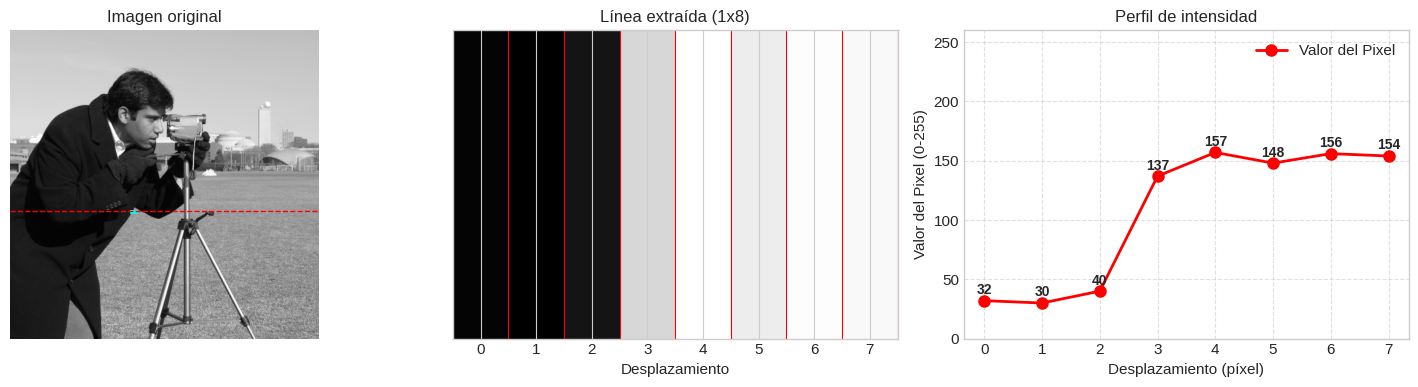

In [3]:
#Imagen de cameraman
imagen = data.camera()

fila = 300
columna_inicio = 200
ancho = 8

fila_linea = imagen[fila, columna_inicio:columna_inicio + ancho]
linea_imagen = imagen[fila:fila+1, columna_inicio:columna_inicio + ancho]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Imagen original
axes[0].imshow(imagen, cmap='gray')
axes[0].axhline(fila, color='red', lw=1, linestyle='--')
rect = plt.Rectangle((columna_inicio, fila - 0.5), ancho, 1, edgecolor='cyan', facecolor='none', lw=2)
axes[0].add_patch(rect)
axes[0].set_title("Imagen original", fontsize=12)
axes[0].axis('off')

#Linea de pixeles
axes[1].imshow(linea_imagen, cmap='gray', aspect='auto', interpolation='nearest')

for i in range(ancho + 1):
    axes[1].axvline(i - 0.5, color='red', lw=0.8)
axes[1].set_title("Línea extraída (1x8)", fontsize=12)
axes[1].set_xlabel("Desplazamiento")
axes[1].set_xticks(np.arange(ancho))
axes[1].set_xticklabels(np.arange(ancho))
axes[1].set_yticks([])

#Perfil de intensidad
axes[2].plot(np.arange(ancho), fila_linea, color='red', marker='o', linestyle='-', linewidth=2, markersize=8,label='Valor del Pixel')

for i, v in enumerate(fila_linea):
    axes[2].text(i, v + 3, str(v), ha='center', va='bottom', fontsize=10, weight='bold')
axes[2].set_title("Perfil de intensidad", fontsize=12)
axes[2].set_xlabel("Desplazamiento (píxel)")
axes[2].set_ylabel("Valor del Pixel (0-255)")
axes[2].set_xticks(np.arange(ancho))
axes[2].set_ylim(0, 260)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


# ¿Que es el Seno y el Coseno?

Imagina un punto que gira sobre una circunferencia de radio 1, a velocidad constante.
En cada instante está en un ángulo $\theta$.

$$\text{posición} = (\cos\theta,\; \sin\theta)$$

- El coseno es la sombra horizontal del punto. O sea su proyeccion sobre el eje x
- El seno es la sombra vertical del punto. O sea su proyeccion sobre el eje y


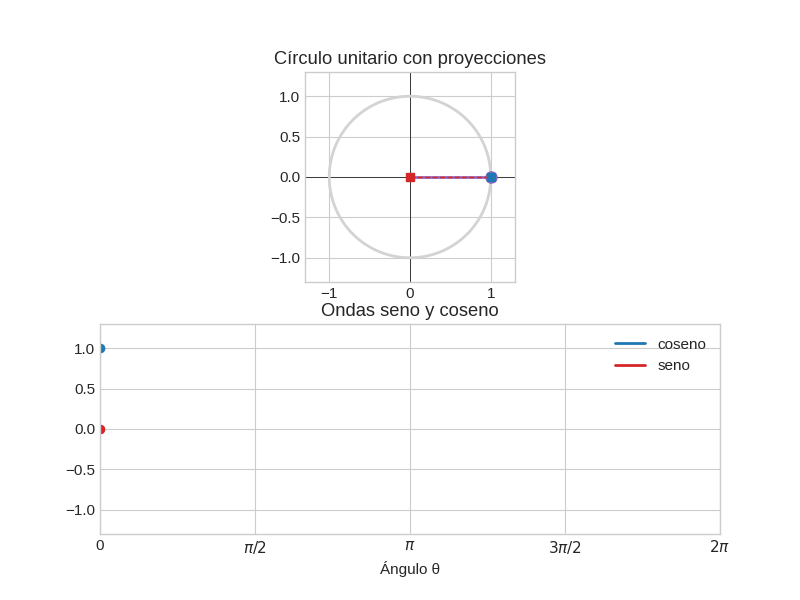

In [4]:
#Parametros
cantidad_fotogramas = 200
angulo_completo = np.linspace(0, 2 * np.pi, 500)
angulos_por_fotograma = np.linspace(0, 2 * np.pi, cantidad_fotogramas)


fig, (eje_circulo, eje_ondas) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 1]})

#Grafico de circulo unitario
eje_circulo.set_xlim(-1.3, 1.3)
eje_circulo.set_ylim(-1.3, 1.3)
eje_circulo.set_aspect('equal')
eje_circulo.axhline(0, color='k', lw=0.5)
eje_circulo.axvline(0, color='k', lw=0.5)
eje_circulo.set_title("Círculo unitario con proyecciones")

#Dibujo de la circunferencia
eje_circulo.plot(np.cos(angulo_completo), np.sin(angulo_completo), color='lightgray', lw=2)

#Cambios por fotograma
linea_radio, = eje_circulo.plot([], [], color='tab:purple', lw=2)
punto_en_circulo, = eje_circulo.plot([], [], 'o', color='tab:purple', ms=8)
sombra_vertical, = eje_circulo.plot([], [], '--', color='tab:blue', lw=1)
sombra_horizontal, = eje_circulo.plot([], [], '--', color='tab:red', lw=1)
proyeccion_x, = eje_circulo.plot([], [], 's', color='tab:blue', ms=6)
proyeccion_y, = eje_circulo.plot([], [], 's', color='tab:red', ms=6)

#Grafico de Ondas
eje_ondas.set_xlim(0, 2 * np.pi)
eje_ondas.set_ylim(-1.3, 1.3)
eje_ondas.set_xlabel("Ángulo θ")
eje_ondas.set_title("Ondas seno y coseno")

marcas_angulos = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
etiquetas_angulos = ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
eje_ondas.set_xticks(marcas_angulos)
eje_ondas.set_xticklabels(etiquetas_angulos)


#Curvas a dibujar
curva_coseno, = eje_ondas.plot([], [], color='tab:blue', lw=2, label='coseno')
curva_seno, = eje_ondas.plot([], [], color='tab:red', lw=2, label='seno')
punto_coseno, = eje_ondas.plot([], [], 'o', color='tab:blue', ms=6)
punto_seno, = eje_ondas.plot([], [], 'o', color='tab:red', ms=6)

eje_ondas.legend(loc='upper right')


def iniciar():
    #Limpiar todo
    linea_radio.set_data([], [])
    punto_en_circulo.set_data([], [])
    sombra_vertical.set_data([], [])
    sombra_horizontal.set_data([], [])
    proyeccion_x.set_data([], [])
    proyeccion_y.set_data([], [])
    curva_coseno.set_data([], [])
    curva_seno.set_data([], [])
    punto_coseno.set_data([], [])
    punto_seno.set_data([], [])
    return (linea_radio, punto_en_circulo, sombra_vertical, sombra_horizontal,
            proyeccion_x, proyeccion_y,
            curva_coseno, curva_seno,punto_coseno, punto_seno)

def actualizar(fotograma):
    #Actualizar por fotograma cada uno de los graficos
    angulo_actual = angulos_por_fotograma[fotograma]
    cos_actual = np.cos(angulo_actual)
    sen_actual = np.sin(angulo_actual)

    #El circulo unitario
    linea_radio.set_data([0, cos_actual], [0, sen_actual])
    punto_en_circulo.set_data([cos_actual], [sen_actual])
    sombra_vertical.set_data([cos_actual, cos_actual], [0, sen_actual])
    sombra_horizontal.set_data([0, cos_actual], [sen_actual, sen_actual])
    proyeccion_x.set_data([cos_actual], [0])
    proyeccion_y.set_data([0], [sen_actual])

    #Las ondas seno y coseno
    cantidad_puntos = max(2, int(200 * angulo_actual / (2 * np.pi)))
    angulos_hasta_ahora = np.linspace(0, angulo_actual, cantidad_puntos)
    if len(angulos_hasta_ahora) >= 2:
        curva_coseno.set_data(angulos_hasta_ahora, np.cos(angulos_hasta_ahora))
        curva_seno.set_data(angulos_hasta_ahora, np.sin(angulos_hasta_ahora))
    else:
        curva_coseno.set_data([], [])
        curva_seno.set_data([], [])

    punto_coseno.set_data([angulo_actual], [cos_actual])
    punto_seno.set_data([angulo_actual], [sen_actual])

    return (linea_radio, punto_en_circulo, sombra_vertical, sombra_horizontal,
            proyeccion_x, proyeccion_y,
            curva_coseno, curva_seno,punto_coseno, punto_seno)

#Creamos la animacion y la guardamos temporalmente
animacion = FuncAnimation(fig, actualizar, frames=cantidad_fotogramas,init_func=iniciar, blit=True, interval=50)


with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as tmp:
    nombre_temporal = tmp.name
try:
    animacion.save(nombre_temporal, writer='pillow', fps=20, dpi=100)

    with open(nombre_temporal, 'rb') as f:
        datos_gif = f.read()
    display(Image(data=datos_gif, format='png'))

finally:
    if os.path.exists(nombre_temporal):
        os.remove(nombre_temporal)

plt.close(fig)

## Seno y coseno son la misma función corrida

Dado el gráfico de arriba podemos apreciar que el seno y coseno es la misma funcion en si solo que variando $\tfrac{\pi}{2}$

$${\;\sin(\theta) = \cos\!\left(\theta - \tfrac{\pi}{2}\right)\;}
\qquad\qquad
{\;\cos(\theta) = \sin\!\left(\theta + \tfrac{\pi}{2}\right)\;}$$

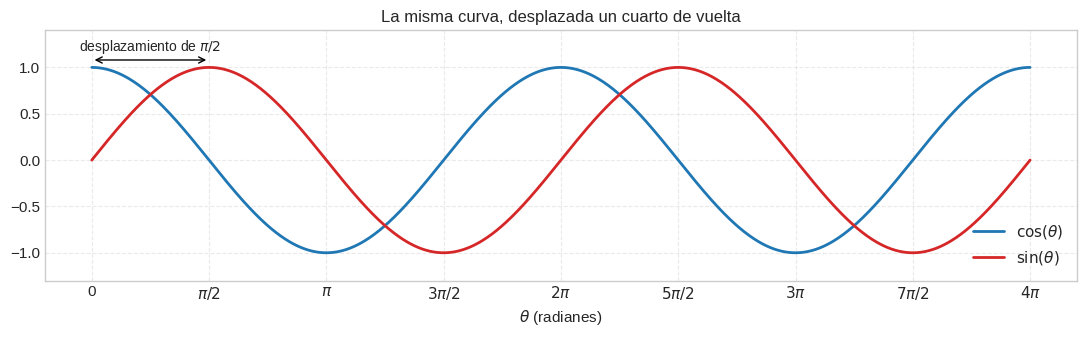

In [5]:
theta = np.linspace(0, 4 * np.pi, 1000)

fig, ax = plt.subplots(figsize=(11, 3.5))

#Curvas
ax.plot(theta, np.cos(theta), lw=2, color='tab:blue', label=r'$\cos(\theta)$')
ax.plot(theta, np.sin(theta), lw=2, color='tab:red',  label=r'$\sin(\theta)$')

#Desfase
ax.annotate("", xy=(np.pi/2, 1.08), xytext=(0, 1.08),arrowprops=dict(arrowstyle='<->', color='k'))
ax.text(np.pi/4, 1.18, r"desplazamiento de $\pi/2$", ha='center', fontsize=10)


angulos = np.arange(0, 4*np.pi + np.pi/2, np.pi/2)
etiquetas = ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$',r'$5\pi/2$', r'$3\pi$', r'$7\pi/2$', r'$4\pi$']
ax.set_xticks(angulos)
ax.set_xticklabels(etiquetas)

ax.set_ylim(-1.3, 1.4)
ax.set_xlabel(r"$\theta$ (radianes)", fontsize=11)
ax.legend(loc='lower right')
ax.set_title("La misma curva, desplazada un cuarto de vuelta", fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Los tres únicos parámetros de una onda

Una onda sinusoidal cualquiera se escribe:

$$s(t) = \underbrace{A}_{\text{amplitud}} \cdot \cos\Big( 2\pi \underbrace{f}_{\text{frecuencia}} t + \underbrace{\varphi}_{\text{fase}} \Big)$$


Donde:

*   **$A$** → **amplitud**: qué tan alta o baja llega la onda (su "tamaño").
*   **$f$** → **frecuencia**: cuántas oscilaciones completas da en 1 segundo. Se mide en **Hz** (vueltas por segundo).
*   **$\varphi$** → **fase**: dónde empieza la onda en $t = 0$ (un corrimiento horizontal)

Y donde muchas veces simplificamos $2\pi f$ a $\omega$

Donde **$\omega$** se llama frecuencia angular y se mide en (rad/s) (Angulo corrido por segundo)

$$ s(t) = A \cdot \cos(\omega t + \varphi) $$

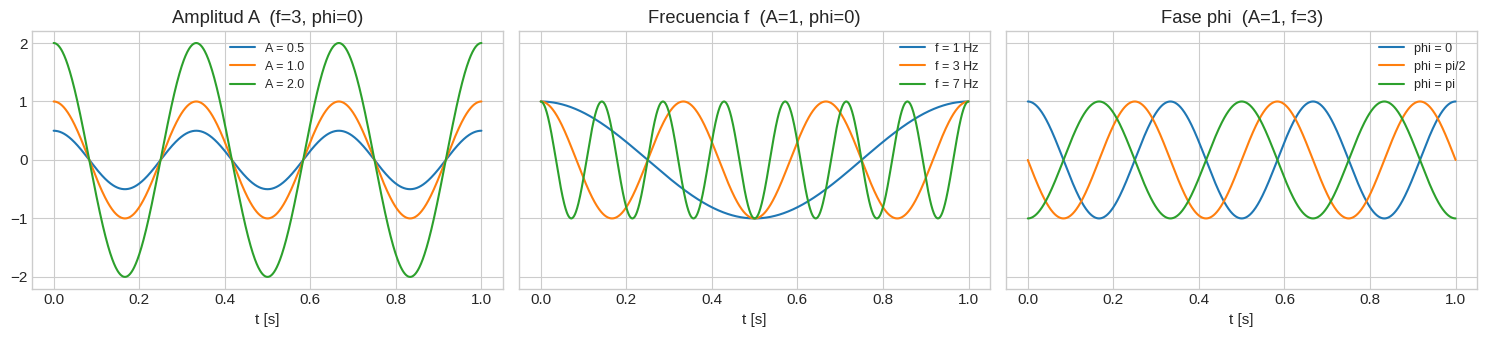

In [6]:
t = np.linspace(0, 1, 1000)

def onda(A, f, phi, t=t):
    return A * np.cos(2*np.pi*f*t + phi)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)

for A in [0.5, 1.0, 2.0]:
    axes[0].plot(t, onda(A, 3, 0), label=f"A = {A}")
axes[0].set_title("Amplitud A  (f=3, phi=0)")

for f in [1, 3, 7]:
    axes[1].plot(t, onda(1, f, 0), label=f"f = {f} Hz")
axes[1].set_title("Frecuencia f  (A=1, phi=0)")

for phi, nombre in [(0, "0"), (np.pi/2, "pi/2"), (np.pi, "pi")]:
    axes[2].plot(t, onda(1, 3, phi), label=f"phi = {nombre}")
axes[2].set_title("Fase phi  (A=1, f=3)")

for ax in axes:
    ax.set_xlabel("t [s]"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## El problema de la fase (y por qué existen $a_n$ y $b_n$)

Hasta ahora hemos usado la representación **$(A, \varphi)$** (amplitud y fase) para describir una onda. Si bien es intuitiva (nos dice "qué tan grande es" y "dónde comienza"), es horrible para hacer calculos.

### Ejemplos de Problemas
Trabajar con la fase $\varphi$ es problemático por tres razones fundamentales:

1. La fase está "atrapada" dentro del coseno: $A\cos(2\pi f t + \varphi)$.
2. Sumar ondas es un dolor de cabeza: Si sumamos dos ondas de la *misma frecuencia*, la amplitud resultante **NO** es la suma de las amplitudes ($A_1 + A_2$) a menos que estén perfectamente alineadas (en fase). Hay que recurrir a engorrosas fórmulas trigonométricas.


### La solución: cambiar de coordenadas

Para librarnos de estos problemas, usamos la **identidad trigonométrica de la suma de ángulos**:

$$ \cos(\alpha + \beta) = \cos\alpha\cos\beta - \sin\alpha\sin\beta $$

Aplicándola a nuestra onda:

$$ A\cos(2\pi f t + \varphi) =
A\cos(2\pi f t)\cos(\varphi) - A\sin(2\pi f t)\sin(\varphi) $$

Ahora, definimos dos nuevos coeficientes que "absorben" la amplitud y la fase:

$$ \boxed{a = A\cos(\varphi)} \quad \text{y} \quad \boxed{b = A\sin(\varphi)} $$


Sustituyendo en la ecuación original....

$$ {\;A\cos(2\pi f t + \varphi) \;=\; a\,\cos(2\pi f t) \;+\; b\,\sin(2\pi f t)\;} $$

### ¿Por Qué Hacemos esto??

Porque ahora es solo trabajar en **álgebra lineal**:

1. **El seno y el coseno son "independientes" (ortogonales)**: No se mezclan entre sí.
2. **Sumar ondas es ahora sumar coeficientes**: Si tenemos dos ondas de la misma frecuencia, la suma se reduce a:

$$ (a_1, b_1) + (a_2, b_2) = (a_1 + a_2, \ b_1 + b_2) $$


<details>
<summary >
    Ver el desarrollo matemático completo (Antes vs Después)
</summary>

## ANTES: Sumar ondas con fases

Tenemos dos ondas de la **misma frecuencia** ($\omega = 2\pi f$), pero con diferentes amplitudes y fases:

$$ s_1(t) = A_1 \cos(\omega t + \varphi_1) $$
$$ s_2(t) = A_2 \cos(\omega t + \varphi_2) $$

Queremos sumarlas para obtener una única onda resultante:

$$ s(t) = s_1(t) + s_2(t) = A \cos(\omega t + \varphi) $$

Desarrollamos cada coseno usando la identidad de la suma de ángulos:

$$ A_1 \cos(\omega t + \varphi_1) = A_1\cos(\omega t)\cos\varphi_1 - A_1\sin(\omega t)\sin\varphi_1 $$
$$ A_2 \cos(\omega t + \varphi_2) = A_2\cos(\omega t)\cos\varphi_2 - A_2\sin(\omega t)\sin\varphi_2 $$

Sumamos y agrupamos términos:

$$ s(t) = \underbrace{(A_1\cos\varphi_1 + A_2\cos\varphi_2)}_{A} \cos(\omega t)
- \underbrace{(A_1\sin\varphi_1 + A_2\sin\varphi_2)}_{B} \sin(\omega t) $$

Luego, para encontrar la amplitud y fase de la resultante hay que aplicar Pitágoras y arco tangente:

$$ \boxed{ A = \sqrt{A^2 + B^2} } \quad , \quad \boxed{ \varphi = \arctan\left(\frac{A}{B}\right) } $$

Es decir, explícitamente:

$$ \boxed{ A = \sqrt{(A_1\cos\varphi_1 + A_2\cos\varphi_2)^2 + (A_1\sin\varphi_1 + A_2\sin\varphi_2)^2} } $$

##DESPUÉS: Sumar ondas con coeficientes (a,b)

Ahora usamos la misma identidad pero para reescribir cada onda antes de sumar.

Definimos para cada onda sus coordenadas cartesianas:

$$ a_i = A_i \cos\varphi_i, \qquad b_i = A_i \sin\varphi_i $$

Entonces CADA onda se reescribe como:

$$ s_i(t) = A_i \cos(\omega t + \varphi_i) = a_i \cos(\omega t) + b_i \sin(\omega t) $$

Luego, ¡Sumar ondas es ahora sumar números sueltos!

Para la suma de las dos ondas:

$$ s(t) = (a_1 + a_2) \cos(\omega t) + (b_1 + b_2) \sin(\omega t) $$

Definimos los coeficientes totales:

$$ \boxed{ a = a_1 + a_2 } \quad  \quad \boxed{ b = b_1 + b_2 } $$


$$ \boxed{ A = \sqrt{a^2 + b^2} } \quad \quad \boxed{ \varphi = \arctan\left(\frac{b}{a}\right) } $$


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


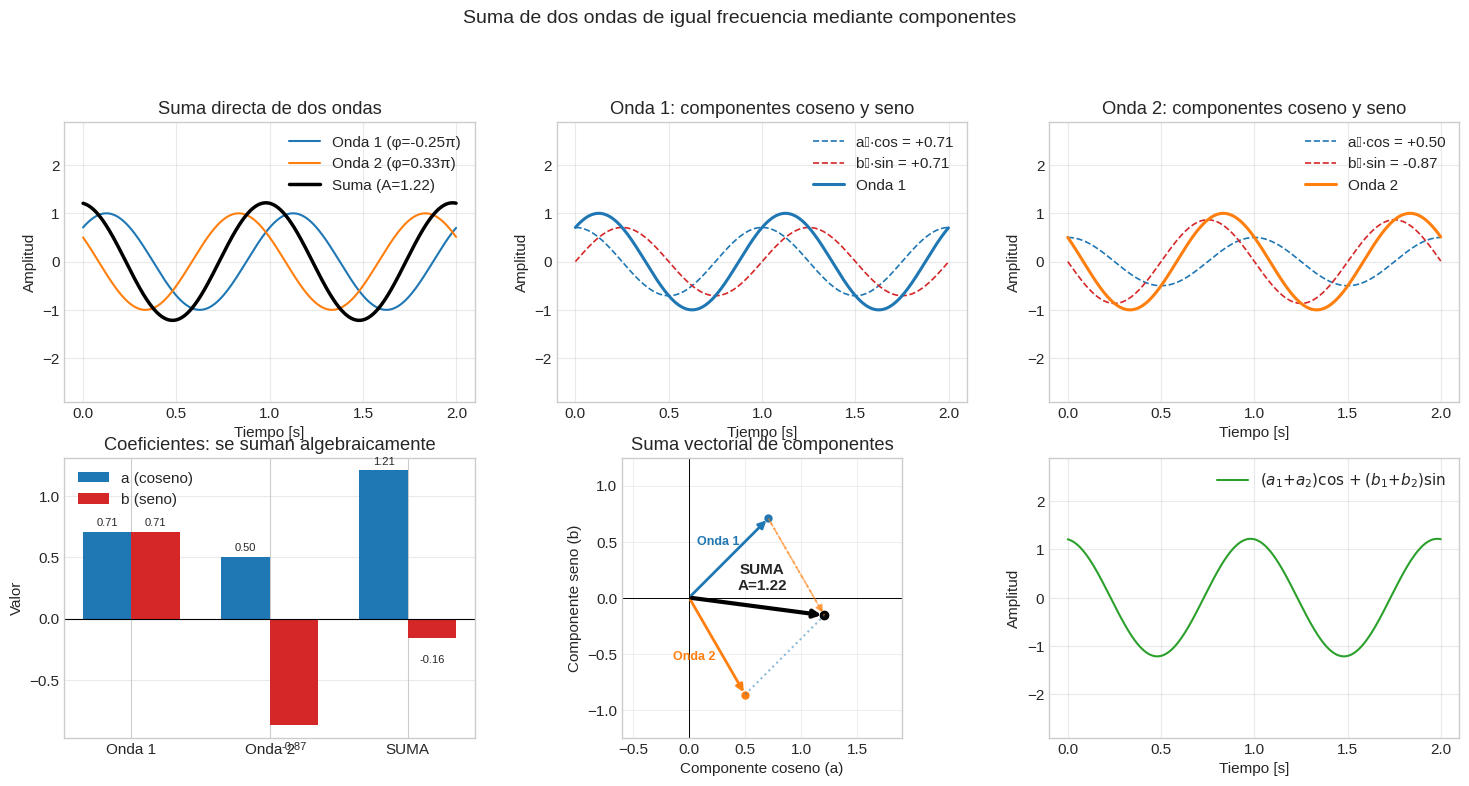

In [7]:
# Parámetros de las ondas
f = 1.0  # frecuencia
A1, phi1 = 1.0, -np.pi/4
A2, phi2 = 1.0,  np.pi/3

t = np.linspace(0, 2/f, 1000, endpoint=False)

onda1 = A1 * np.cos(2*np.pi*f*t + phi1)
onda2 = A2 * np.cos(2*np.pi*f*t + phi2)
suma_directa = onda1 + onda2

# Componentes (a = A·cos(phi), b = -A·sin(phi))
a1, b1 = A1*np.cos(phi1), -A1*np.sin(phi1)
a2, b2 = A2*np.cos(phi2), -A2*np.sin(phi2)
a_total, b_total = a1 + a2, b1 + b2

suma_por_componentes = a_total*np.cos(2*np.pi*f*t) + b_total*np.sin(2*np.pi*f*t)

A_total = np.hypot(a_total, b_total)
phi_total = np.arctan2(-b_total, a_total)


#--GRAFICOS---
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# (0,0) las dos ondas y su suma
ax = axes[0, 0]
ax.plot(t, onda1, color='tab:blue', lw=1.5, label=f'Onda 1 (φ={phi1/np.pi:.2f}π)')
ax.plot(t, onda2, color='tab:orange', lw=1.5, label=f'Onda 2 (φ={phi2/np.pi:.2f}π)')
ax.plot(t, suma_directa, color='k', lw=2.5, label=f'Suma (A={A_total:.2f})')
ax.set_title("Suma directa de dos ondas")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud")
ax.legend(loc='upper right')
ax.set_ylim(-2.9, 2.9)
ax.grid(True, alpha=0.4)

# (0,1) descomposicion de onda 1
ax = axes[0, 1]
ax.plot(t, a1*np.cos(2*np.pi*f*t), '--', color='tab:blue', lw=1.2, label=f'a₁·cos = {a1:+.2f}')
ax.plot(t, b1*np.sin(2*np.pi*f*t), '--', color='tab:red',  lw=1.2, label=f'b₁·sin = {b1:+.2f}')
ax.plot(t, onda1, color='tab:blue', lw=2.2, label='Onda 1')
ax.set_title("Onda 1: componentes coseno y seno")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud")
ax.legend(loc='upper right')
ax.set_ylim(-2.9, 2.9)
ax.grid(True, alpha=0.4)

# (0,2) descomposicion de onda 2
ax = axes[0, 2]
ax.plot(t, a2*np.cos(2*np.pi*f*t), '--', color='tab:blue', lw=1.2, label=f'a₂·cos = {a2:+.2f}')
ax.plot(t, b2*np.sin(2*np.pi*f*t), '--', color='tab:red',  lw=1.2, label=f'b₂·sin = {b2:+.2f}')
ax.plot(t, onda2, color='tab:orange', lw=2.2, label='Onda 2')
ax.set_title("Onda 2: componentes coseno y seno")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud")
ax.legend(loc='upper right')
ax.set_ylim(-2.9, 2.9)
ax.grid(True, alpha=0.4)

# (1,0) barras de coeficientes
ax = axes[1, 0]
pos = np.arange(3)
width = 0.35
bars_a = ax.bar(pos - width/2, [a1, a2, a_total], width, color='tab:blue', label='a (coseno)')
bars_b = ax.bar(pos + width/2, [b1, b2, b_total], width, color='tab:red',  label='b (seno)')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(pos)
ax.set_xticklabels(['Onda 1', 'Onda 2', 'SUMA'])
ax.set_title("Coeficientes: se suman algebraicamente")
ax.set_ylabel("Valor")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4, axis='y')

for bar in bars_a + bars_b:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3 if height >= 0 else -12),textcoords='offset points',
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=8)
# (1,1) Suma vectorial en el plano (a,b)
ax = axes[1, 1]
# Dibujar vectores
for (aa, bb, color, label, dx, dy) in [
    (a1, b1, 'tab:blue',   'Onda 1', -0.32,  0.08),
    (a2, b2, 'tab:orange', 'Onda 2', -0.42, -0.08)
]:
    ax.annotate("", xy=(aa, bb), xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=2))
    ax.plot(aa, bb, 'o', color=color, ms=5)
    ax.text(aa*0.55 + dx, bb*0.55 + dy, label, color=color, fontsize=9,
            fontweight='bold')

# Paralelogramo: trasladar onda2 al extremo de onda1
ax.annotate("", xy=(a_total, b_total), xytext=(a1, b1),
            arrowprops=dict(arrowstyle='-|>', color='tab:orange', lw=1.2,
                            ls='--', alpha=0.6))
# Vector suma
ax.annotate("", xy=(a_total, b_total), xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='k', lw=3))
ax.plot(a_total, b_total, 'ko', ms=6)
ax.text(a_total*0.5 + 0.05, b_total*0.5 + 0.15, f'SUMA\nA={A_total:.2f}',
        fontweight='bold', ha='center')

ax.plot([a2, a_total], [b2, b_total], ':', color='tab:blue', alpha=0.5)
ax.plot([a1, a_total], [b1, b_total], ':', color='tab:orange', alpha=0.5)

ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.set_xlim(-0.6, 1.9)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect('equal')
ax.set_xlabel("Componente coseno (a)")
ax.set_ylabel("Componente seno (b)")
ax.set_title("Suma vectorial de componentes")
ax.grid(True, alpha=0.3)

# (1,2) Verificación
ax = axes[1, 2]
ax.plot(t, suma_por_componentes, color='tab:green', lw=1.5,
        label=r'$(a_1{+}a_2)\cos + (b_1{+}b_2)\sin$')
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud")
ax.legend(loc='upper right')
ax.set_ylim(-2.9, 2.9)
ax.grid(True, alpha=0.4)

plt.suptitle("Suma de dos ondas de igual frecuencia mediante componentes", fontsize=14, y=1.02)
plt.show()


# 2. SERIE DE FOURIER = Sumar ondas

> ### Serie de Fourier
> **Cualquier señal razonable se puede escribir como una SUMA de ondas simples.**


$$f(t) \;=\; \sum_n \Big( a_n \cos(2\pi n f_0 t) + b_n \sin(2\pi n f_0 t) \Big)$$


Hay una **combinación lineal**

Las frecuencias $n f_0$ (múltiplos enteros de una frecuencia base $f_0$) se llaman **armónicos**

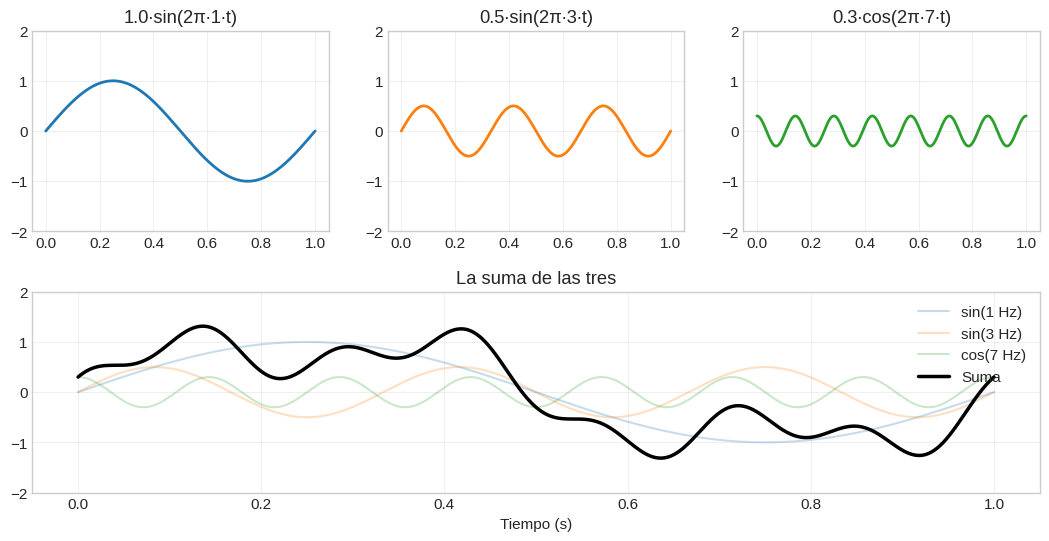

In [8]:
t = np.linspace(0, 1, 1000)

o1 = 1.0 * np.sin(2 * np.pi * 1 * t)
o2 = 0.5 * np.sin(2 * np.pi * 3 * t)
o3 = 0.3 * np.cos(2 * np.pi * 7 * t)
suma = o1 + o2 + o3

fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.3)

#Graficos individuales
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t, o1, color='tab:blue', lw=2)
ax1.set_title("1.0·sin(2π·1·t)")
ax1.set_ylim(-2, 2)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t, o2, color='tab:orange', lw=2)
ax2.set_title("0.5·sin(2π·3·t)")
ax2.set_ylim(-2, 2)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(t, o3, color='tab:green', lw=2)
ax3.set_title("0.3·cos(2π·7·t)")
ax3.set_ylim(-2, 2)
ax3.grid(True, alpha=0.3)

#Grafico de la suma resultante
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(t, o1, color='tab:blue', alpha=0.25, label='sin(1 Hz)')
ax4.plot(t, o2, color='tab:orange', alpha=0.25, label='sin(3 Hz)')
ax4.plot(t, o3, color='tab:green', alpha=0.25, label='cos(7 Hz)')
ax4.plot(t, suma, color='k', lw=2.5, label='Suma')
ax4.set_title("La suma de las tres")
ax4.set_ylim(-2, 2)
ax4.set_xlabel("Tiempo (s)")
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper right')

plt.show()

## Caso de ejemplo

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-np.pi, np.pi, 2000)

# Onda cuadrada ideal
cuadrada = np.where(x >= 0, 1.0, -1.0)

def reconstruir_cuadrada(K):
    s = np.zeros_like(x)
    for n in range(1, K+1, 2):
        s += (4.0 / (n * np.pi)) * np.sin(n * x)
    return s

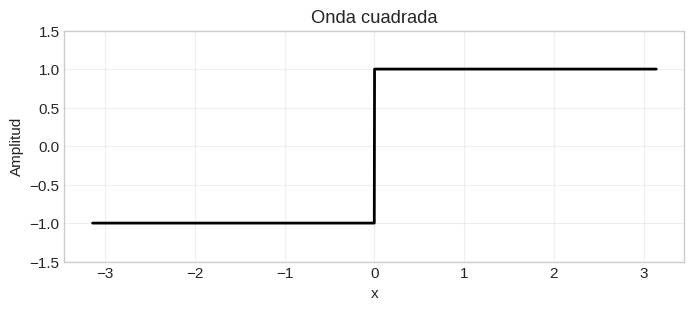

In [10]:
plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k-', lw=2)
plt.title("Onda cuadrada")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

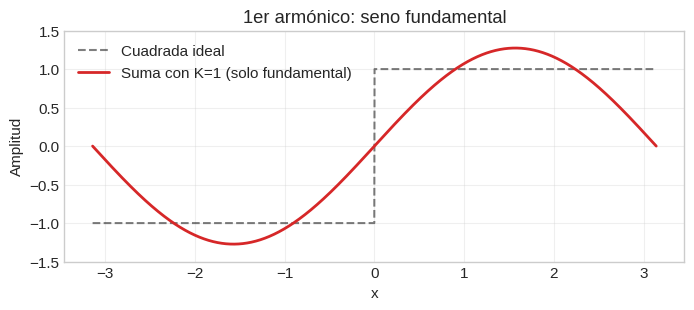

In [11]:
K = 1
s1 = reconstruir_cuadrada(K)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.5, label='Cuadrada ideal')
plt.plot(x, s1, 'tab:red', lw=2, label=f'Suma con K={K} (solo fundamental)')
plt.title("1er armónico: seno fundamental")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

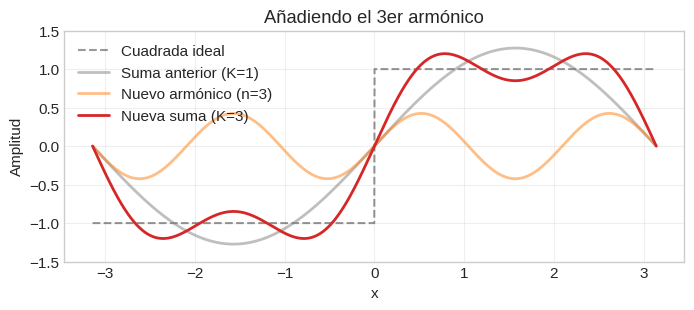

In [12]:
K_prev = 1
K_new = 3
s_prev = reconstruir_cuadrada(K_prev)
s_new = reconstruir_cuadrada(K_new)

# El nuevo armónico es la diferencia
armonico_nuevo = (4.0/(3*np.pi)) * np.sin(3*x)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.4, label='Cuadrada ideal')
plt.plot(x, s_prev, 'gray', lw=2, alpha=0.5, label=f'Suma anterior (K={K_prev})')
plt.plot(x, armonico_nuevo, 'tab:orange', lw=2, alpha=0.5, label='Nuevo armónico (n=3)')
plt.plot(x, s_new, 'tab:red', lw=2, label=f'Nueva suma (K={K_new})')
plt.title("Añadiendo el 3er armónico")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

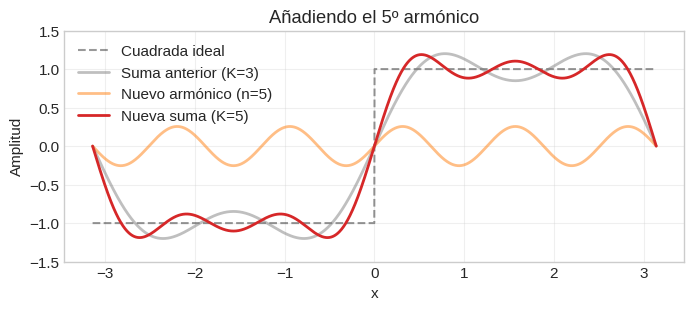

In [13]:
K_prev = 3
K_new = 5
s_prev = reconstruir_cuadrada(K_prev)
s_new = reconstruir_cuadrada(K_new)

armonico_nuevo = (4.0/(5*np.pi)) * np.sin(5*x)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.4, label='Cuadrada ideal')
plt.plot(x, s_prev, 'gray', lw=2, alpha=0.5, label=f'Suma anterior (K={K_prev})')
plt.plot(x, armonico_nuevo, 'tab:orange', lw=2, alpha=0.5, label='Nuevo armónico (n=5)')
plt.plot(x, s_new, 'tab:red', lw=2, label=f'Nueva suma (K={K_new})')
plt.title("Añadiendo el 5º armónico")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

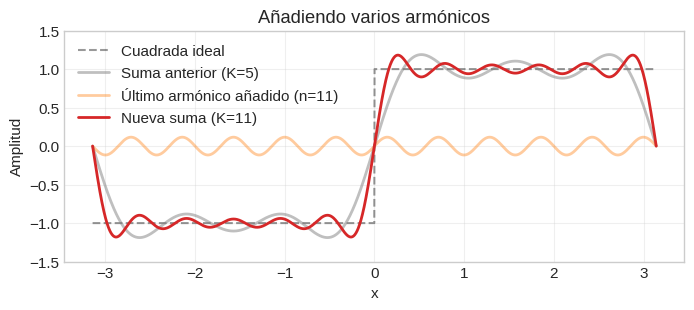

In [14]:
K_prev = 5
K_new = 11
s_prev = reconstruir_cuadrada(K_prev)
s_new = reconstruir_cuadrada(K_new)

armonico_nuevo = (4.0/(11*np.pi)) * np.sin(11*x)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.4, label='Cuadrada ideal')
plt.plot(x, s_prev, 'gray', lw=2, alpha=0.5, label=f'Suma anterior (K={K_prev})')
plt.plot(x, armonico_nuevo, 'tab:orange', lw=2, alpha=0.4, label='Último armónico añadido (n=11)')
plt.plot(x, s_new, 'tab:red', lw=2, label=f'Nueva suma (K={K_new})')
plt.title("Añadiendo varios armónicos")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

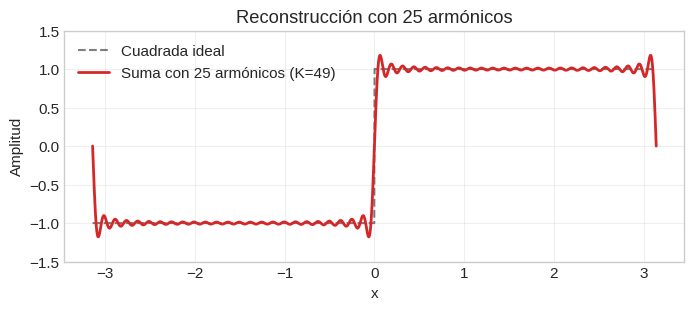

In [15]:
K = 49
s = reconstruir_cuadrada(K)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.5, label='Cuadrada ideal')
plt.plot(x, s, 'tab:red', lw=2, label=f'Suma con {len(range(1,K+1,2))} armónicos (K={K})')
plt.title("Reconstrucción con 25 armónicos")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

# El producto interno: el medidor de parecido



> - La operación que mide **proyección, similitud, ángulo y solapamiento** es el
>   **producto interno** (o escalar), y devuelve **un número**:
>   $$\langle \vec{u}, \vec{v} \rangle = \sum_{i=1}^n u_i v_i$$
>
> ¿No podriamos inyectarle una funcion y una base y ver que onda?

### ¿Qué hace el producto interno geométricamente?
1. **Mide parecido / alineación:**
   - Si dos vectores apuntan en la misma dirección, su producto interno es positivo y grande.
   - Si son **perpendiculares (ortogonales)**, $\langle \vec{u}, \vec{v} \rangle = 0$.
2. **Extrae coordenadas (Proyección):**
   Si tenemos una base ortonormal canónica en $\mathbb{R}^3$, por ejemplo $\hat{e}_1 = (1, 0, 0)$, y un vector cualquiera $v = (v_1, v_2, v_3)$:
   $$c_1 = \vec{v} \cdot \hat{e}_1 = v_1 \cdot 1 + _2 \cdot 0 + v_3 \cdot 0 = v_1$$

**El producto interno actúa como un "sensor"**: cuando hacés el producto interno de $\vec{v}$ contra un vector de la base $\hat{e}_i$, el producto anula todas las demás componentes y **pesca únicamente la coordenada en esa dirección**.

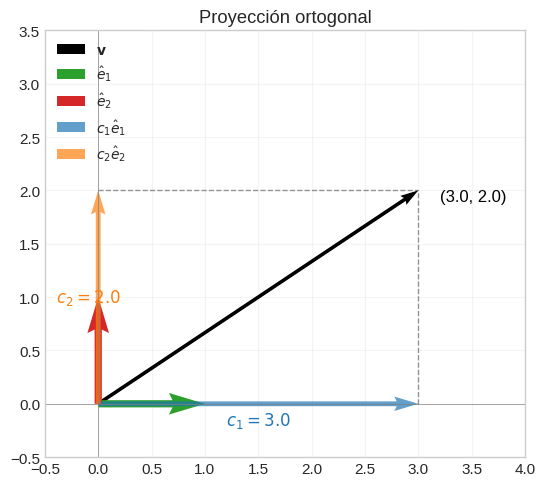

In [16]:
v = np.array([3.0, 2.0])
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

c1 = np.dot(v, e1)
c2 = np.dot(v, e2)


fig, ax = plt.subplots(figsize=(6, 5))

ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,color='k', linewidth=2, label=r'$\mathbf{v}$')

ax.quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1,color='tab:green', width=0.015, label=r'$\hat{e}_1$')
ax.quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1,color='tab:red', width=0.015, label=r'$\hat{e}_2$')

# Proyecciones
proy_x = c1 * e1
proy_y = c2 * e2
ax.quiver(0, 0, proy_x[0], proy_x[1], angles='xy', scale_units='xy', scale=1,color='tab:blue', alpha=0.7, width=0.01, label=r'$c_1 \hat{e}_1$')
ax.quiver(0, 0, proy_y[0], proy_y[1], angles='xy', scale_units='xy', scale=1, color='tab:orange', alpha=0.7, width=0.01, label=r'$c_2 \hat{e}_2$')

# Líneas auxiliares
ax.plot([v[0], v[0]], [0, v[1]], 'k--', alpha=0.4, lw=1)
ax.plot([0, v[0]], [v[1], v[1]], 'k--', alpha=0.4, lw=1)

# Anotaciones
ax.text(v[0]/2, -0.2, f'$c_1 = {c1}$', ha='center', fontsize=12, color='tab:blue')
ax.text(-0.4, v[1]/2, f'$c_2 = {c2}$', va='center', fontsize=12, color='tab:ORANGE')
ax.text(v[0]+0.2, v[1]-0.1, f'({v[0]}, {v[1]})', fontsize=12, color='k')

# Ajustes del gráfico
ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 3.5)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')
ax.set_title("Proyección ortogonal")
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Tenemos el vector $\mathbf{v} = (3, 2)$ y la base canónica  
$\hat{e}_1 = (1, 0)$, $\hat{e}_2 = (0, 1)$.

Queremos expresar $\mathbf{v}$ como **combinación lineal** de la base:

$$ \mathbf{v} = c_1 \hat{e}_1 + c_2 \hat{e}_2 $$

De forma general, si tenemos una base ortonormal $\{\hat{e}_1, \hat{e}_2, \dots, \hat{e}_n\}$, la expresión se escribe como una **sumatoria**:

$$ \mathbf{v} = \sum_{i=1}^{n} c_i \hat{e}_i, \qquad c_i = \langle \mathbf{v}, \hat{e}_i \rangle $$

En nuestro caso, $n=2$:

$$ \mathbf{v} = \sum_{i=1}^{2} c_i \hat{e}_i = c_1 \hat{e}_1 + c_2 \hat{e}_2 $$

Los coeficientes se obtienen mediante el **producto interno** (producto punto):

$$ c_1 = \langle \mathbf{v}, \hat{e}_1 \rangle, \qquad c_2 = \langle \mathbf{v}, \hat{e}_2 \rangle $$

- Para $c_1$:

$$ c_1 = \langle (3, 2), (1, 0) \rangle
      = 3 \cdot 1 + 2 \cdot 0
      = 3 + 0
      = 3 $$

- Para $c_2$:

$$ c_2 = \langle (3, 2), (0, 1) \rangle
      = 3 \cdot 0 + 2 \cdot 1
      = 0 + 2
      = 2 $$

**Reconstrucción:**

$$ c_1 \hat{e}_1 + c_2 \hat{e}_2
   = 3 \cdot (1, 0) + 2 \cdot (0, 1)
   = (3, 0) + (0, 2)
   = (3, 2) = \mathbf{v} $$



## El Espacio de Funciones: Vectores de Infinitas Dimensiones

Una función/señal muestreada es un vector. Entonces el producto interno es el mismo:

$$\langle f, g \rangle = \sum_{i=1}^{N} f_i \, g_i$$

Y, achicando el paso de muestreo ($\Delta x \to 0$)....
$$\langle f, g \rangle = \int_a^b f(x)\, g(x)\, dx$$

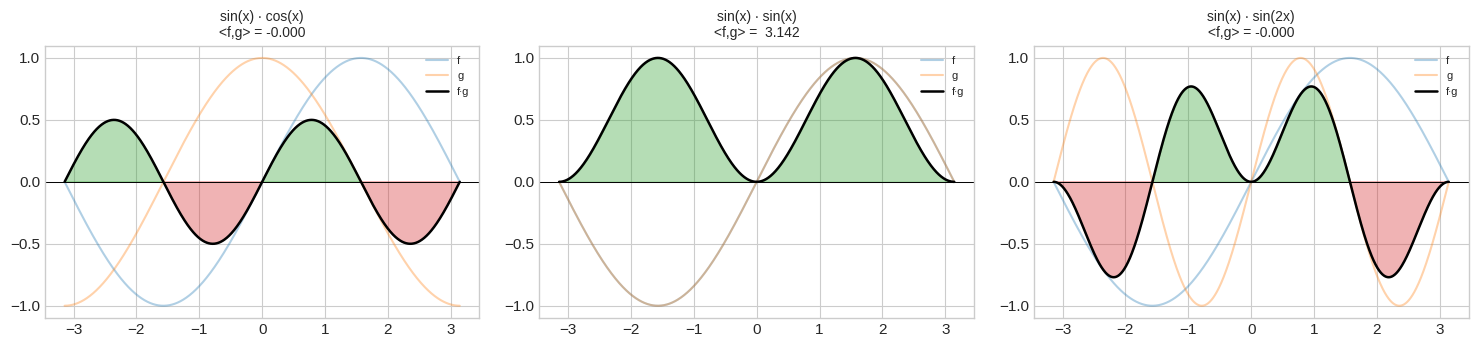

In [17]:
x = np.linspace(-np.pi, np.pi, 1000)
dx = x[1] - x[0]

pares = [(np.sin(x), np.cos(x), "sin(x) · cos(x)"),
         (np.sin(x), np.sin(x), "sin(x) · sin(x)"),
         (np.sin(x), np.sin(2*x), "sin(x) · sin(2x)")]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (f, g, nombre) in zip(axes, pares):
    prod = f * g
    ax.plot(x, f, alpha=0.35, label='f')
    ax.plot(x, g, alpha=0.35, label='g')
    ax.plot(x, prod, color='k', lw=1.8, label='f·g')
    ax.fill_between(x, prod, where=prod >= 0, color='tab:green', alpha=0.35)
    ax.fill_between(x, prod, where=prod <  0, color='tab:red',   alpha=0.35)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_title(f"{nombre}\n<f,g> = {np.sum(prod)*dx: .3f}", fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


# Correlación y convolución: el producto interno deslizante



El producto interno $\langle f, g\rangle$ compara dos señales cuando están perfectamente superpuestas.
Pero en la vida real:

> Tengo una señal $f$ y busco un patrón $g$, **pero no sé dónde aparece**.

La solución es obvia: deslizo el patrón por toda la señal y en cada posición hago un producto interno. Me queda una **nueva señal**: un número por cada desplazamiento.

$$(f \star g)[t] \;=\; \sum_{\tau} f[\tau]\; g[\tau + t]
\qquad\qquad \text{(correlación cruzada)}$$

o, en versión continua, exactamente lo mismo con el otro símbolo de suma:

$$(f \star g)(t) \;=\; \int_{-\infty}^{\infty} f(\tau)\, g(\tau + t)\, d\tau$$

> **La Correlacion es un "escáner de producto interno":**
> En cada instante $t$, la correlacion calcula el producto interno entre $f$ y $g$. Si en algún instante las dos formas coinciden, el producto interno produce un pico máximo.

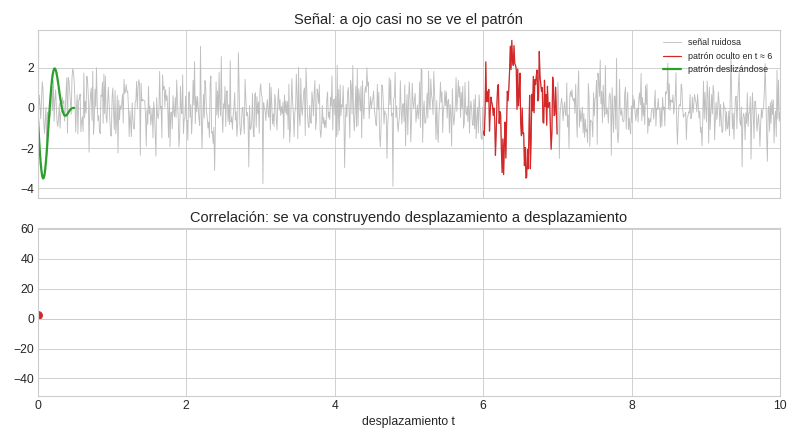

In [18]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

if 'senal' not in globals():
    rng = np.random.default_rng(0)
    t = np.linspace(0, 10, 1000)
    x = np.linspace(0, 1, 100)
    patron = np.hanning(100) * np.sin(2*np.pi*3*x)
    senal = rng.normal(0, 1.0, t.size)
    senal[600:700] += 3*patron

N, M = senal.size, patron.size
corr = np.correlate(senal, patron, mode='same')

FRAMES = 180
idx = np.linspace(0, N-1, FRAMES).astype(int)
esc  = 0.9*np.abs(senal).max()/np.abs(patron).max()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

ax1.plot(t, senal, color='0.75', lw=0.8, label='señal ruidosa')
ax1.plot(t[600:700], senal[600:700], color='tab:red', lw=1.1, label='patrón oculto en t ≈ 6')
mov, = ax1.plot([], [], color='tab:green', lw=2, label='patrón deslizándose')
vl1  = ax1.axvline(t[0], color='tab:green', ls=':', lw=1)
ax1.set_ylim(1.15*senal.min(), 1.15*senal.max())
ax1.set_title("Señal: a ojo casi no se ve el patrón"); ax1.legend(fontsize=8, loc='upper right')

linea, = ax2.plot([], [], color='tab:blue', lw=2)
punto, = ax2.plot([], [], 'o', color='tab:red', ms=7)
ax2.set_ylim(1.15*corr.min(), 1.15*corr.max()); ax2.set_xlim(t[0], t[-1])
ax2.axhline(0, color='0.8', lw=0.8)
ax2.set_title("Correlación: se va construyendo desplazamiento a desplazamiento")
ax2.set_xlabel("desplazamiento t")
plt.tight_layout()

def update(f):
    k = idx[f]
    a  = k - M//2
    lo, hi = max(a, 0), min(a + M, N)
    mov.set_data(t[lo:hi], patron[lo-a:hi-a]*esc)
    vl1.set_xdata([t[k], t[k]])
    linea.set_data(t[:k+1], corr[:k+1])
    punto.set_data([t[k]], [corr[k]])
    return mov, vl1, linea, punto

ani = FuncAnimation(fig, update, frames=FRAMES, interval=50, blit=True)
ani.save('correlacion.gif', writer=PillowWriter(fps=25), dpi=80)
plt.close(fig)

display(Image('correlacion.gif'))


##¿Cómo se consiguen los coeficientes $a_n$ y $b_n$?

Hemos visto que cualquier señal periódica se puede escribir como:

$$ f(t) = a_0 + \sum_{n=1}^{\infty} \left[ a_n \cos(n\omega_0 t) + b_n \sin(n\omega_0 t) \right] $$

Pero... **¿cómo obtenemos esos números $a_n$ y $b_n$ a partir de una señal concreta?**

Aplicamos lo anterior, producto interno entre funciones


$$ \langle f, g \rangle = \int_0^T f(t) \, g(t) \, dt $$

Si la base está formada por las funciones $\cos(n\omega_0 t)$ y $\sin(n\omega_0 t)$, **el coeficiente $a_n$ se obtiene proyectando $f(t)$ sobre $\cos(n\omega_0 t)$**:

$$ a_n \propto \langle f(t), \cos(n\omega_0 t) \rangle $$

##Normalizamos

Cuando calculamos el producto interno de una función base consigo misma, obtenemos un número que **no es 1**. Por ejemplo:

- Para la constante $1$:  
  $$ \langle 1, 1 \rangle = \int_0^T 1 \cdot 1 \, dt = T $$
- Para $\cos(n\omega_0 t)$:  
  $$ \langle \cos(n\omega t), \cos(n\omega t) \rangle = \int_0^T \cos^2(n\omega t) \, dt = \frac{T}{2} $$
- Para $\sin(n\omega t)$:  
  $$ \langle \sin(n\omega t), \sin(n\omega t) \rangle = \frac{T}{2} $$

Si usamos el producto interno directamente, el coeficiente que "pescamos" viene escalado por señal en si. A nosotros nos interesa solo cuanto se "parece" en magnitud a la señal real.

Por eso:

- Para $a_0$:  
  $$ a_0= \frac{1}{T} \int_0^T f(t) \, dt $$

- Para $a_n$:  
  $$ a_n =  \frac{2}{T} \int_0^T f(t) \cos(n\omega t) \, dt $$

- Para $b_n$:  
  $$ b_n = \frac{2}{T} \int_0^T f(t) \sin(n\omega t) \, dt $$




#Euler: de $(a_n, b_n)$ a un único $c_n$

Tener dos juegos de coeficientes ($a_n$ para cosenos y $b_n$ para senos) es engorroso.

Por eso usamos laidentidad de euler:
$$\mathbf{e^{i\theta} = \cos(\theta) + i\sin(\theta)}$$

### ¿Por qué esto simplifica todo?
Ahora tenemos una base exponencial compleja en vez de bases trigonométricas
$$\mathcal{B}_{compleja} = \{ \dots, e^{-i2x}, e^{-ix}, 1, e^{ix}, e^{i2x}, \dots \}$$

Cualquier función se escribe como una única serie:
$$\mathbf{f(x) = \sum_{n=-\infty}^\infty c_n e^{inx}}$$

¿Y cómo calculamos la coordenada compleja $c_n$?
Nuevamente con el **producto interno** (en espacios complejos usamos el conjugado $\langle f, g \rangle = \int f(x) \overline{g(x)} dx$):
$$\mathbf{c_n = \frac{1}{2\pi} \int_{-\pi}^\pi f(x) e^{-inx} dx}$$

### ¿Qué representa geométricamente el número complejo $c_n$?
Cada $c_n$ es un vector en el plano complejo:
- **Su magnitud $|c_n|$:** es la **amplitud** (cuánta energía o peso tiene esa frecuencia).
- **Su ángulo $\angle c_n$:** es la **fase** (cuánto está desplazada horizontalmente esa onda).

$$c_n = |c_n| e^{i \phi_n} = \underbrace{|c_n|}_{\text{Amplitud}} \angle \underbrace{\phi_n}_{\text{Fase}}$$

# De la serie a la transformada: el salto de lo periódico a lo aperiódico

## El punto de partida

Hasta ahora trabajamos con señales **periódicas**, que se repiten cada $T$ segundos. Su espectro es **discreto**: solo existe energía en los múltiplos enteros de la fundamental $f_0 = 1/T$.

$$ f(t) = \sum_{n=-\infty}^{\infty} c_n \, e^{\,i 2\pi n f_0 t}, \qquad c_n = \frac{1}{T}\int_{T} f(t)\, e^{-i 2\pi n f_0 t}\, dt $$

Cada $c_n$ es un número: la amplitud y fase del armónico $n$-ésimo. El espectro es un conjunto de rayas separadas por $f_0$.

## El problema

¿Y si la señal **no se repite**? Un solo pulso, un golpe de tambor, un audio de dos segundos. No hay $T$, no hay $f_0$, no hay armónicos.

## La idea

Forzamos el caso: tomamos la señal aperiódica y la imaginamos como una periódica cuyo período **crece sin límite**, $T \to \infty$. Miramos qué le pasa a cada pieza de la serie:

| Serie de Fourier ($T$ finito) | Transformada ($T \to \infty$) |
|---|---|
| Fundamental $f_0 = 1/T$ | $f_0 \to 0$: separación infinitesimal, $df$ |
| Armónicos $n f_0$ (discretos) | Todas las frecuencias $f \in \mathbb{R}$ (continuo) |
| Coeficientes $c_n$ (una lista) | Función $F(f)$ (un continuo) |
| Sumatoria $\sum_n$ | Integral $\int df$ |

Las rayas del espectro se juntan hasta tocarse y forman una curva continua.

## Definición

Para una señal $f(t)$ no periódica en tiempo continuo, la **transformada de Fourier** es

En frecuencia angular $\omega$ (rad/s):

$$ F(\omega) = \int_{-\infty}^{\infty} f(t)\, e^{-i\omega t}\, dt $$

En frecuencia ordinaria $f$ (Hz):

$$ F(f) = \int_{-\infty}^{\infty} f(t)\, e^{-i 2\pi f t}\, dt $$

> **Interpretación.** $F(f)$ es un **continuo de coeficientes**. Donde antes teníamos la lista $c_0, c_1, c_2, \dots$, ahora tenemos una función que le asigna a **cada** frecuencia real $f$ una amplitud $|F(f)|$ y una fase $\arg F(f)$.

Y para volver al dominio del tiempo, en lugar de sumar armónicos, integramos todas las frecuencias:

$$f(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} F(\omega) e^{i\omega t} \, d\omega$$



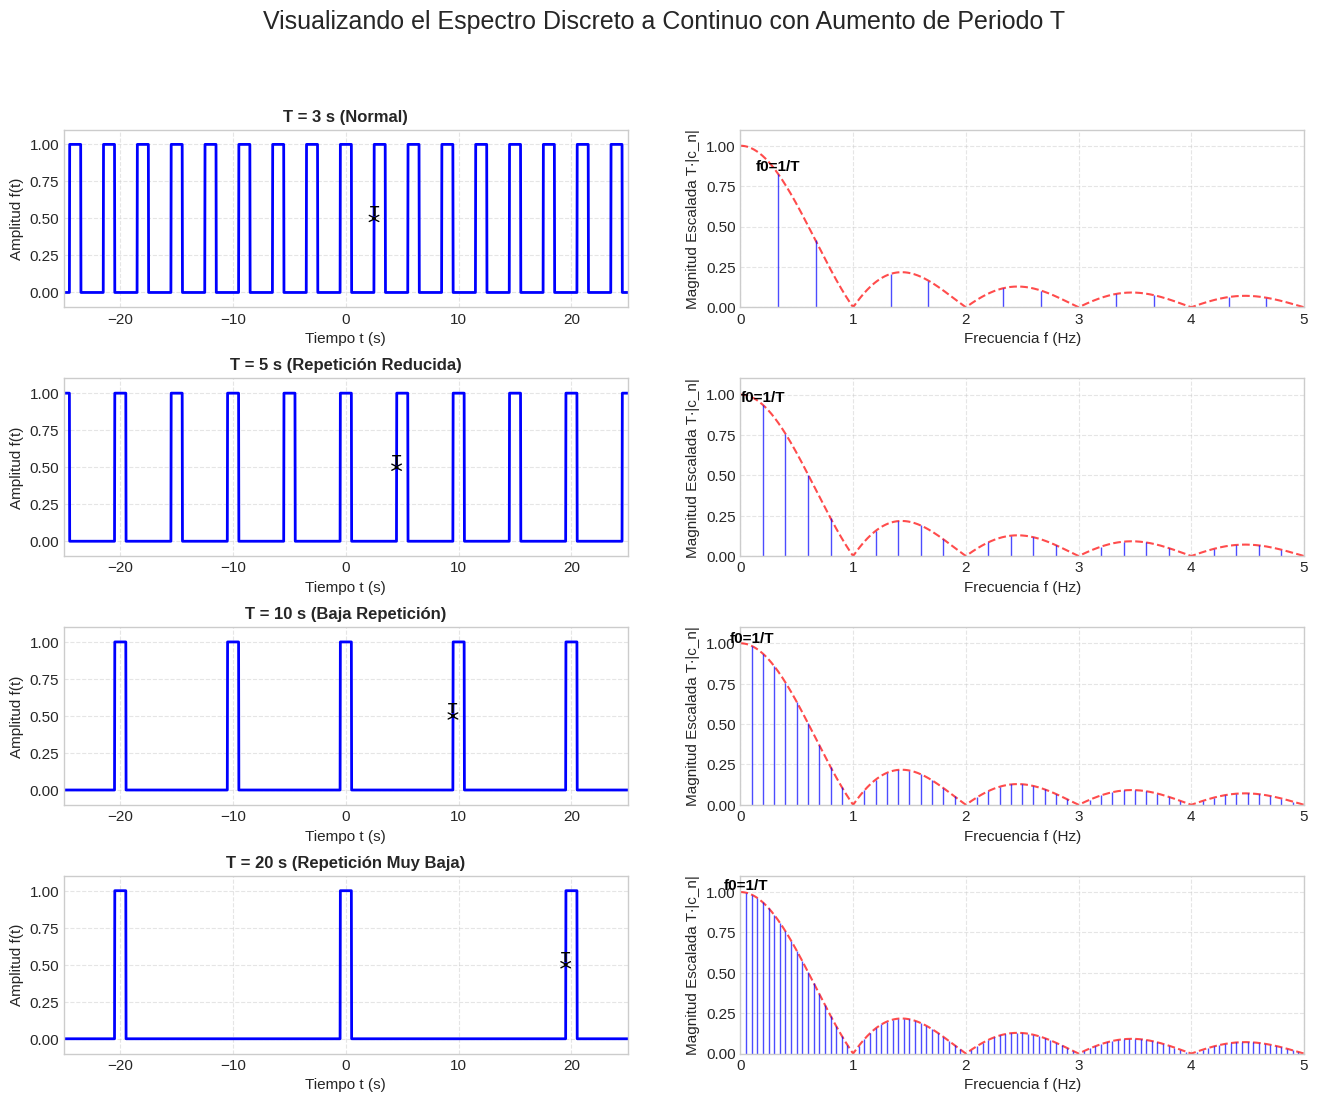

In [19]:
tau = 1.0  # Ancho del pulso en segundos
A = 1.0    # Amplitud del pulso
f_max = 5.0 # Frecuencia máxima a graficar (Hz)

# Lista de periodos T a graficar
periods = [3, 5, 10, 20]


def sinc_function(f, A, tau):
    return np.abs(A * tau * np.sinc(f * tau))

def calc_c_n_mags(f0, A, tau, n_vals):
    return np.abs(A * tau * np.sinc(n_vals * f0 * tau))

def pulse_train(t, A, tau, T):
    t_shift = (t + T / 2) % T - T / 2
    y_array = np.zeros_like(t)
    y_array[np.abs(t_shift) <= tau / 2] = A
    return y_array

fig, axes = plt.subplots(4, 2, figsize=(16, 12), gridspec_kw={'hspace': 0.4, 'wspace': 0.2})
fig.suptitle('Visualizando el Espectro Discreto a Continuo con Aumento de Periodo T', fontsize=18)

t = np.linspace(-25, 25, 2000)

for i, T in enumerate(periods):
    ax_time = axes[i, 0]
    y_time = pulse_train(t, A, tau, T)
    ax_time.plot(t, y_time, lw=2, color='blue')
    ax_time.set_xlim(-25, 25)
    ax_time.set_ylim(-0.1, A + 0.1)
    ax_time.set_xlabel('Tiempo t (s)')
    ax_time.set_ylabel('Amplitud f(t)')
    ax_time.grid(True, linestyle='--', alpha=0.5)

    # Título de callout específico para la fila
    titles_list = ["T = 3 s (Normal)",
                   "T = 5 s (Repetición Reducida)",
                   "T = 10 s (Baja Repetición)",
                   "T = 20 s (Repetición Muy Baja)"]
    ax_time.set_title(titles_list[i], fontsize=12, fontweight='bold')

    ax_time.text(0, A + 0.02, '', color='black', ha='center', fontweight='bold')
    ax_time.annotate('', xy=(T, 0.5), xytext=(T - tau, 0.5), arrowprops=dict(arrowstyle='<->', color='black'))
    ax_time.text(T - tau/2, 0.52, 'T', color='black', ha='center', fontweight='bold')

    ax_freq = axes[i, 1]

    f_cont = np.linspace(0.0001, f_max, 1000)
    ax_freq.plot(f_cont, sinc_function(f_cont, A, tau), 'r--', lw=1.5, alpha=0.7)

    if i == 0:
        ax_freq.text(f_max, sinc_function(f_max, A, tau) + 0.05, '',
                     color='red', ha='right', fontweight='bold')

    f0 = 1 / T
    n_max = int(f_max / f0)
    ns = np.arange(1, n_max + 1)
    freqs_discrete = ns * f0

    scaled_cn_mags = calc_c_n_mags(f0, A, tau, ns)

    ax_freq.vlines(freqs_discrete, 0, scaled_cn_mags, color='b', alpha=0.7, lw=1)

    if i == 0:
        ax_freq.text(2, scaled_cn_mags[int(2/f0)], '',
                     color='blue', ha='left', fontweight='bold')

    ax_freq.text(f0 * (ns[0] if len(ns)>0 else 1), scaled_cn_mags[0] + 0.02, 'f0=1/T',
                 color='black', ha='center', fontweight='bold')

    ax_freq.set_xlim(0, f_max)
    ax_freq.set_ylim(0, A * tau + 0.1)
    ax_freq.set_xlabel('Frecuencia f (Hz)')
    ax_freq.set_ylabel('Magnitud Escalada T·|c_n|')
    ax_freq.grid(True, linestyle='--', alpha=0.5)

plt.show()


# 8. La DFT: la versión de la computadora

En una computadora una señal no tiene infinitos puntos continuos: tiene $N$ muestras.

$$\vec{x} = [x_0, x_1, \dots, x_{N-1}]^T$$

Y entonces:
- la integral **se convierte de nuevo en una suma finita**
- las frecuencias posibles **son finitas**: sólo $N$ de ellas,
- todo se puede escribir como **una multiplicación matriz por vector**.

$$X_k = \sum_{n=0}^{N-1} x_n\, e^{-i\frac{2\pi}{N}kn}
\qquad\Longleftrightarrow\qquad
\boxed{\;\vec{X} = W\vec{x}\;}$$

donde $W$ es la **matriz de Fourier**, $W_{kn} = e^{-i\frac{2\pi}{N}kn}$:

$$\begin{bmatrix} X_0 \\ X_1 \\ \vdots \\ X_{N-1}\end{bmatrix} =
\begin{bmatrix}
1 & 1 & 1 & \dots & 1\\
1 & W_N & W_N^2 & \dots & W_N^{N-1}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & W_N^{N-1} & W_N^{2(N-1)} & \dots & W_N^{(N-1)^2}
\end{bmatrix}
\begin{bmatrix} x_0 \\ x_1 \\ \vdots \\ x_{N-1}\end{bmatrix},
\qquad W_N = e^{-i\frac{2\pi}{N}}$$

**Cada fila $k$ de $W$ es una onda discreta** de frecuencia $k$ (parte real: coseno; parte imaginaria: $-$seno).
Multiplicar $W\vec{x}$ es hacer **un producto interno de la señal contra cada onda**. Nada más.

### ¿Qué propiedades tiene la matriz $W$?
1. Sus columnas son **ortogonales** entre sí en $\mathbb{C}^N$.
2. Por lo tanto, su inversa es simplemente su **traspuesta conjugada** (dividida por $N$):
   $$\mathbf{W^{-1} = \frac{1}{N} W^H}$$
3. Reconstrucción (IDFT):
   $$\vec{x} = \frac{1}{N} W^H \vec{X}$$

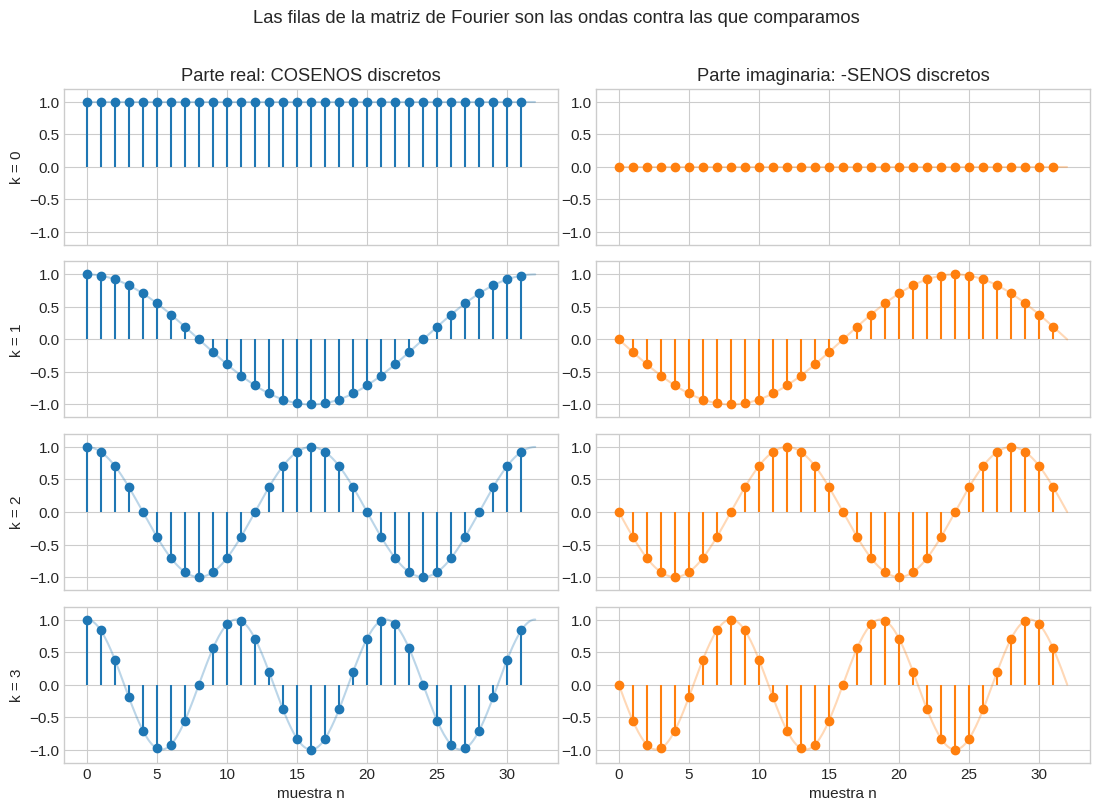

In [20]:
# Cantidad de muestras
N = 32

# Índices de las muestras
n = np.arange(N)

W = np.exp(-2j * np.pi * np.outer(np.arange(N), n) / N)

fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharex=True)
for k_idx in range(4):
    axes[k_idx, 0].stem(n, np.real(W[k_idx, :]), basefmt=" ")
    axes[k_idx, 0].set_ylabel(f"k = {k_idx}")
    axes[k_idx, 1].stem(n, np.imag(W[k_idx, :]), basefmt=" ", linefmt='tab:orange', markerfmt='o')

    tt = np.linspace(0, N, 300)
    axes[k_idx, 0].plot(tt, np.cos(2*np.pi*k_idx*tt/N), color='tab:blue', alpha=0.3)
    axes[k_idx, 1].plot(tt, -np.sin(2*np.pi*k_idx*tt/N), color='tab:orange', alpha=0.3)
    axes[k_idx, 0].set_ylim(-1.2, 1.2); axes[k_idx, 1].set_ylim(-1.2, 1.2)
axes[0, 0].set_title("Parte real: COSENOS discretos")
axes[0, 1].set_title("Parte imaginaria: -SENOS discretos")
axes[-1, 0].set_xlabel("muestra n"); axes[-1, 1].set_xlabel("muestra n")
plt.suptitle("Las filas de la matriz de Fourier son las ondas contra las que comparamos", y=1.01)
plt.tight_layout()
plt.show()

## La DFT escrita como correlación

Escribamos la DFT con los `for` explícitos para ver que es exactamente un **producto interno entre la señal y cada onda de Fourier**:

$$
X_k =
\sum_{t=0}^{N-1}
x_t[\cos(2\pi kt/N)-i\sin(2\pi kt/N)]
$$



# 1. Ejercicio

Programá la transformada de Fourier discreta desde cero, usando la fórmula anterior y **sin utilizar `np.fft`**.

El resultado \(X_k\) es un número complejo. De él podemos obtener:

$$
|X_k| = \text{cuánto hay de la frecuencia } k
$$

$$
\angle X_k = \text{fase de la frecuencia } k
$$


In [21]:
def mi_dft(x):
  """
  Calcula la DFT de una señal x (real o compleja) usando los bucles explícitos.
  """
  N = len(x)
  X = np.zeros(N, dtype=complex)

  for k in range(N):
    suma = 0.0j

    for t in range(N):
      pass

    X[k] = suma

  return X

In [22]:
class TestMiDFT(unittest.TestCase):

  def test_tamano_salida(self):
    x = np.random.default_rng(0).normal(size=10)
    X = mi_dft(x)
    self.assertEqual(len(X), len(x),f"El tamaño esperado es {len(x)}, pero se obtuvo {len(X)}")

  def test_delta_identidad(self):
        # Un impulso en la posición 0 debe transformarse en un vector de unos
        x = np.zeros(8)
        x[0] = 1.0
        X = mi_dft(x)
        esperado = np.ones(8)
        np.testing.assert_allclose(X, esperado, atol=1e-10, err_msg="La DFT de un delta en t=0 debe ser todo unos")

  def test_constante(self):
      # Una señal constante debe tener solo componente en k=0, igual a N
      N = 8
      x = np.ones(N)
      X = mi_dft(x)
      self.assertAlmostEqual(X[0], N, delta=1e-10, msg="La componente DC debe ser N")
      np.testing.assert_allclose(X[1:], 0, atol=1e-10, err_msg="Las demás componentes deben ser cero")

In [23]:
if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestMiDFT)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)

    if resultado.wasSuccessful():
        print("\n Todos los tests de DFT 1D pasaron correctamente.")
    else:
        print("\n Algunos tests de DFT 1D fallaron. Revisá la implementación.")

FAIL: test_constante (__main__.TestMiDFT.test_constante)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_2404/1984248929.py", line 21, in test_constante
    self.assertAlmostEqual(X[0], N, delta=1e-10, msg="La componente DC debe ser N")
    ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: np.complex128(0j) != 8 within 1e-10 delta (np.float64(8.0) difference) : La componente DC debe ser N

FAIL: test_delta_identidad (__main__.TestMiDFT.test_delta_identidad)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_2404/1984248929.py", line 14, in test_delta_identidad
    np.testing.assert_allclose(X, esperado, atol=1e-10, err_msg="La DFT de un delta en t=0 debe ser todo unos")
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi


 Algunos tests de DFT 1D fallaron. Revisá la implementación.


test 1: esto les da casi 0? si => 👍
512.7671587136065
test 2: picos en 5, 40 y 120? si => 👍


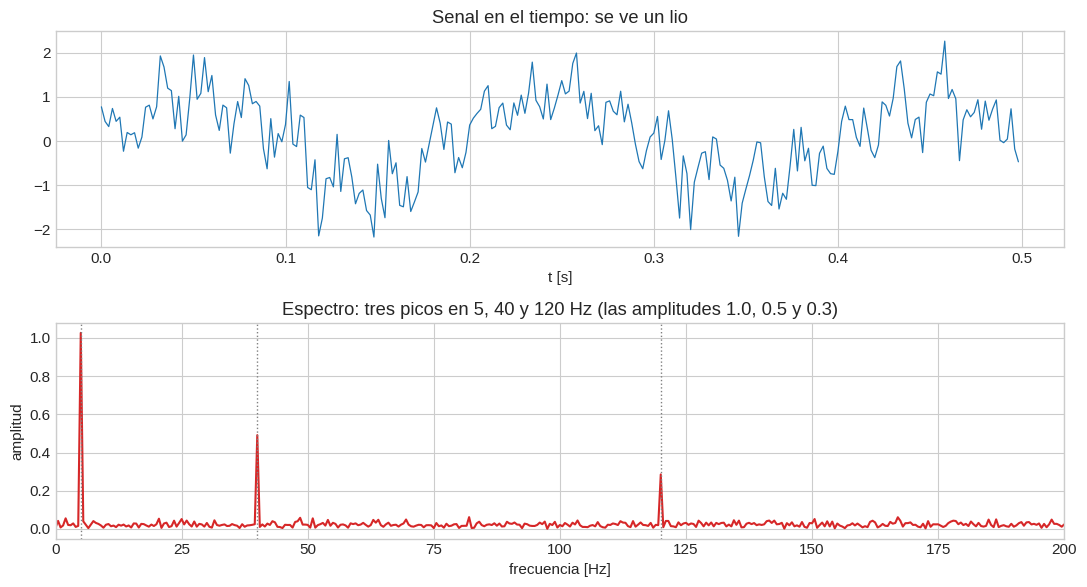

In [24]:
# Señal con tres tonos escondidos + ruido: la DFT los saca a la luz
fs = 500.0
T  = 2.0
t  = np.arange(0, T, 1/fs)
N  = len(t)
señal = (1.0*np.sin(2*np.pi*  5*t) +
         0.5*np.sin(2*np.pi* 40*t) +
         0.3*np.cos(2*np.pi*120*t) +
         0.4*rng.normal(0, 1, N))


print("test 1: esto les da casi 0? si => 👍")
X_mia = mi_dft(señal)
X_numpy = np.fft.fft(señal)
print(np.max(np.abs(X_mia - X_numpy)))

print("test 2: picos en 5, 40 y 120? si => 👍")
X     = fft(señal)
freqs = fftfreq(N, 1/fs)
mitad = freqs >= 0                       # nos quedamos con la mitad util

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1.plot(t[:250], señal[:250], lw=0.9)
ax1.set_title("Senal en el tiempo: se ve un lio"); ax1.set_xlabel("t [s]")

ax2.plot(freqs[mitad], 2*np.abs(X[mitad])/N, color='tab:red')
ax2.set_xlim(0, 200); ax2.set_xlabel("frecuencia [Hz]"); ax2.set_ylabel("amplitud")
ax2.set_title("Espectro: tres picos en 5, 40 y 120 Hz (las amplitudes 1.0, 0.5 y 0.3)")
for f0 in (5, 40, 120):
    ax2.axvline(f0, color='gray', ls=':', lw=1)
plt.tight_layout()
plt.show()


# Fourier 2D: imágenes

Todo lo anterior se transplanta sin cambios. Lo único nuevo es que ahora hay **dos índices**.

$$F(u, v) = \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x,y)\, e^{-i2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}$$

### Las funciones base ahora son **ondas planas**
Una base 2D es una onda que oscila en una **dirección** del plano. Tiene:
- una frecuencia horizontal $u$,
- una frecuencia vertical $v$,
- y por lo tanto una **orientación** $\theta = \arctan(v/u)$ y una **frecuencia total** $\sqrt{u^2+v^2}$.

Visualmente: **franjas** (rayas) más o menos juntas, con una inclinación.
Una imagen es una **superposición de rayas**.

### La DFT 2D es **separable**
$$F = W\, f\, W^T$$
Aplicás la matriz de Fourier a las **filas** y después a las **columnas**. Por eso es barata.

### Cómo se lee un espectro (con `fftshift`, el cero al centro)
| Dónde | Qué es en la imagen |
| :-- | :-- |
| **Centro** (bajas frecuencias) | fondos, zonas lisas, iluminación general, formas grandes |
| **Periferia** (altas frecuencias) | bordes, texturas finas, detalle, ruido |
| **Dirección** de un pico | orientación de las rayas: un pico *horizontal* ⇒ rayas *verticales* |
| **Píxel central** $F(0,0)$ | la suma de todos los píxeles = el brillo promedio |

u = frecuencia horizontal (rayas verticales)
v = frecuencia vertical   (rayas horizontales)
u y v juntos -> rayas inclinadas


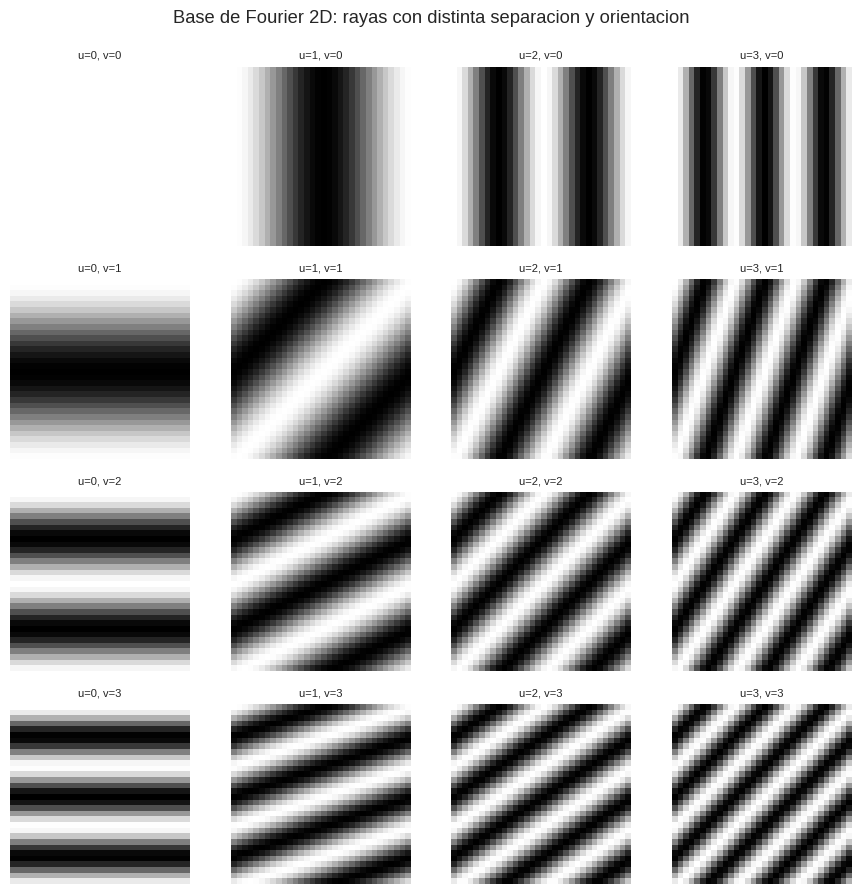

In [25]:
# Las bases 2D: ondas planas con distintas frecuencias horizontal y vertical
def base_2d(size, u, v):
    M, N = size
    y, x = np.mgrid[0:M, 0:N]
    return np.cos(2*np.pi*(u*x/N + v*y/M))

U, V = 4, 4

print("u = frecuencia horizontal (rayas verticales)")
print("v = frecuencia vertical   (rayas horizontales)")
print("u y v juntos -> rayas inclinadas")

fig, axes = plt.subplots(V, U, figsize=(9, 9))
for v in range(V):
    for u in range(U):
        axes[v, u].imshow(base_2d((32, 32), u, v), cmap='gray', vmin=-1, vmax=1)
        axes[v, u].set_title(f"u={u}, v={v}", fontsize=8)
        axes[v, u].axis('off')
plt.suptitle("Base de Fourier 2D: rayas con distinta separacion y orientacion", y=0.99)
plt.tight_layout(); plt.show()


# 2. Ejercicio

Programá la transformada de Fourier discreta en dos dimensiones desde cero, usando las siguientes fórmulas y **sin utilizar `np.fft2`**.

### DFT 2D

Partimos de la DFT bidimensional:

$$
F(u,v)=
\sum_{y=0}^{M-1}
\sum_{x=0}^{N-1}
f(x,y)
e^{-i2\pi\left(\frac{ux}{N}+\frac{vy}{M}\right)}
$$

Como la exponencial se puede separar:

$$
e^{-i2\pi\left(\frac{ux}{N}+\frac{vy}{M}\right)}
=
e^{-i2\pi\frac{ux}{N}}
e^{-i2\pi\frac{vy}{M}}
$$

podemos calcular la DFT en dos etapas.

### 1. DFT de cada fila

Para cada fila $y$:

$$
G(u,y)
=
\sum_{x=0}^{N-1}
f(x,y)
e^{-i2\pi\frac{ux}{N}}
$$

### 2. DFT de cada columna

Luego aplicamos la DFT a cada columna de $G$:

$$
F(u,v)
=
\sum_{y=0}^{M-1}
G(u,y)
e^{-i2\pi\frac{vy}{M}}
$$

Por lo tanto, podemos pensar el algoritmo como:

$$
f(x,y)
\xrightarrow{\text{DFT de filas}}
G(u,y)
\xrightarrow{\text{DFT de columnas}}
F(u,v)
$$

In [26]:
def mi_fft2(imagen):
    """
    Calcula la DFT 2D de una imagen (o matriz) usando la separabilidad.
    """
    # DFT de cada fila
    DFT_filas = np.zeros_like(imagen, dtype=complex)

    for i in range(imagen.shape[0]):
        pass

    # DFT de cada columna
    DFT_columnas = np.zeros_like(imagen, dtype=complex)

    for j in range(imagen.shape[1]):
        pass

    return DFT_columnas

In [27]:
class TestMiFFT2(unittest.TestCase):

    def test_tamano_salida(self):
        # La DFT 2D debe devolver una matriz del mismo tamaño que la entrada
        imagen = np.random.default_rng(42).normal(size=(8, 6))
        F = mi_fft2(imagen)
        self.assertEqual(F.shape, imagen.shape,
                         f"El tamaño esperado es {imagen.shape}, pero se obtuvo {F.shape}")

    def test_delta_identidad(self):
        #Un impulso en (0,0) debe transformarse en una matriz constante de unos
        imagen = np.zeros((5, 4), dtype=complex)
        imagen[0, 0] = 1.0
        F = mi_fft2(imagen)
        esperado = np.ones_like(imagen)
        np.testing.assert_allclose(F, esperado, atol=1e-10, err_msg="La DFT 2D de un delta en (0,0) debe ser todo unos")

In [28]:
if __name__ == '__main__':
    suite = unittest.TestLoader().loadTestsFromTestCase(TestMiFFT2)
    resultado = unittest.TextTestRunner(verbosity=0).run(suite)

    if resultado.wasSuccessful():
        print("\n Todos los tests de DFT 2D pasaron correctamente.")
    else:
        print("\n Algunos tests de DFT 2D fallaron. Revisá la implementación.")

FAIL: test_delta_identidad (__main__.TestMiFFT2.test_delta_identidad)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_2404/4210986389.py", line 16, in test_delta_identidad
    np.testing.assert_allclose(F, esperado, atol=1e-10, err_msg="La DFT 2D de un delta en (0,0) debe ser todo unos")
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/numpy/testing/_private/utils.py", line 1691, in assert_allclose
    assert_array_compare(compare, actual, desired, err_msg=str(err_msg),
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                         verbose=verbose, header=header, equal_nan=equal_nan,
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                         strict=strict)
                         ^^^^^^^^^^^^^^
  File "/usr/lib/py


 Algunos tests de DFT 2D fallaron. Revisá la implementación.


test: si las imagenes de arriba les quedan muy parecidas a las de abaj0 => 👍


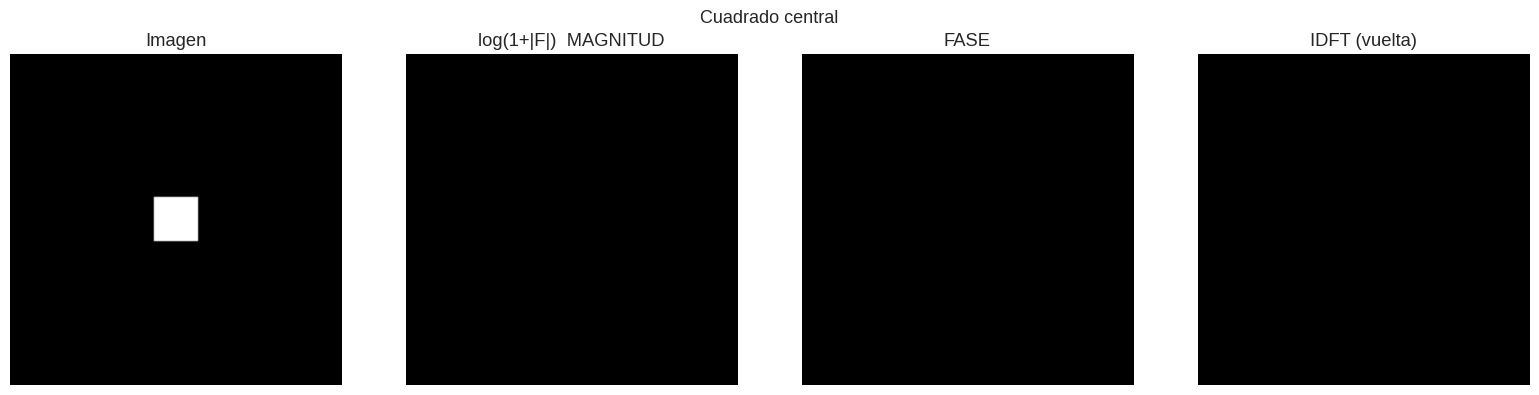

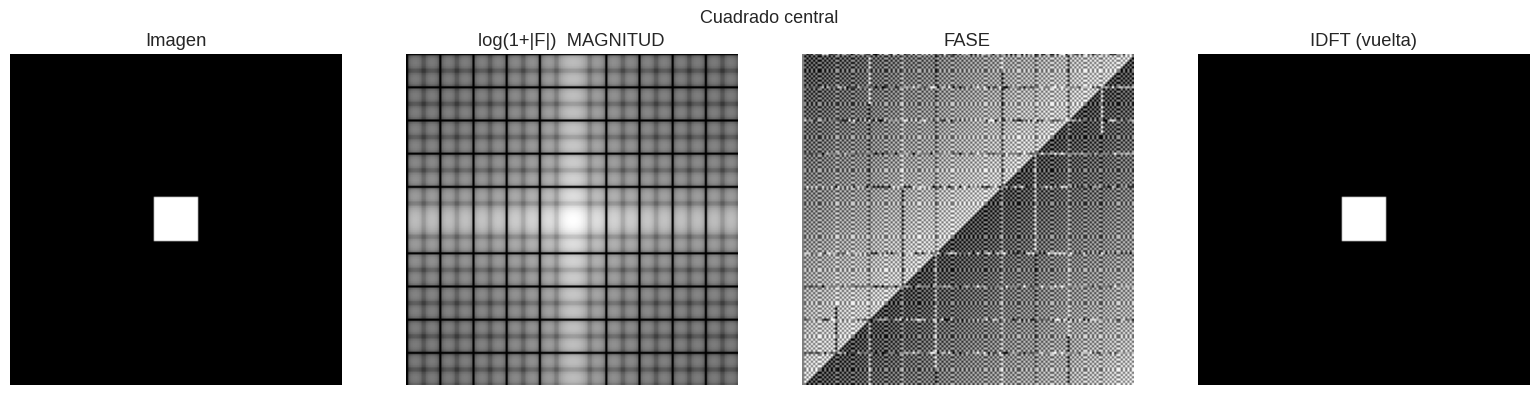

In [29]:
# Funciones auxiliares que vamos a reutilizar
def espectro_log(F):
    # log(1 + |F|) centrado: sin el log solo se ve un punto en el centro
    return np.log1p(np.abs(fftshift(F)))

def mostrar_dft(imagen, titulo="", F = None):
    if F== "mi_fft2":
      f = mi_fft2(imagen)
    else:
      f = fft2(imagen)
    recon = np.real(ifft2(f))
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(imagen, cmap='gray');            axes[0].set_title("Imagen")
    axes[1].imshow(espectro_log(f), cmap='gray');   axes[1].set_title("log(1+|F|)  MAGNITUD")
    axes[2].imshow(np.angle(fftshift(f)), cmap='gray'); axes[2].set_title("FASE")
    axes[3].imshow(recon, cmap='gray');             axes[3].set_title("IDFT (vuelta)")
    for ax in axes: ax.axis('off')
    fig.suptitle(titulo, fontsize=13)
    plt.tight_layout(); plt.show()
    return f

D = 150
cuadrado = np.zeros((D, D)); rr, cc = rectangle(start=(65, 65), extent=(20, 20)); cuadrado[rr, cc] = 255
print("test: si las imagenes de arriba les quedan muy parecidas a las de abaj0 => 👍")
_ = mostrar_dft(cuadrado, "Cuadrado central", F="mi_fft2")
_ = mostrar_dft(cuadrado, "Cuadrado central")

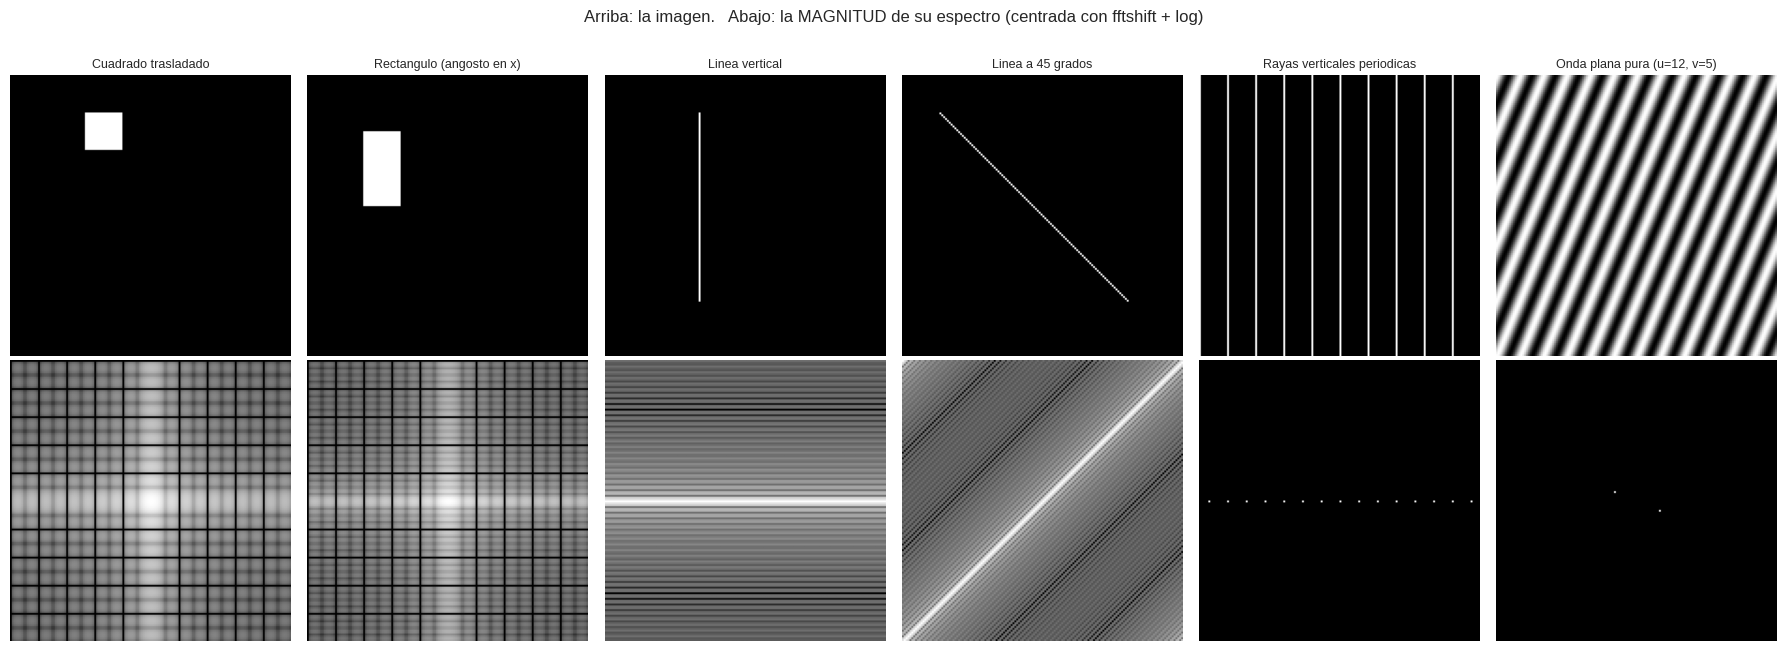

In [30]:
# Galeria: como se ve el espectro de formas geometricas simples
figuras = {}

img = np.zeros((D, D)); rr, cc = rectangle(start=(20, 40), extent=(20, 20)); img[rr, cc] = 255
figuras["Cuadrado trasladado"] = img

img = np.zeros((D, D)); rr, cc = rectangle(start=(30, 30), extent=(40, 20)); img[rr, cc] = 255
figuras["Rectangulo (angosto en x)"] = img

img = np.zeros((D, D)); rr, cc = line(20, 50, 120, 50); img[rr, cc] = 255
figuras["Linea vertical"] = img

img = np.zeros((D, D)); rr, cc = line(20, 20, 120, 120); img[rr, cc] = 255
figuras["Linea a 45 grados"] = img

img = np.zeros((D, D)); img[:, ::15] = 255      # peine perfectamente periodico
figuras["Rayas verticales periodicas"] = img

img = base_2d((D, D), 12, 5)
figuras["Onda plana pura (u=12, v=5)"] = img

fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))
for j, (nombre, im) in enumerate(figuras.items()):
    axes[0, j].imshow(im, cmap='gray'); axes[0, j].set_title(nombre, fontsize=9); axes[0, j].axis('off')
    axes[1, j].imshow(espectro_log(fft2(im)), cmap='gray'); axes[1, j].axis('off')
plt.suptitle("Arriba: la imagen.   Abajo: la MAGNITUD de su espectro (centrada con fftshift + log)",
             y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

## Filtrado en el espacio de la frecuencia

Una vez que tenemos la transformada de Fourier de una imagen:

$$
F(u,v)=\mathcal{F}\{f(x,y)\}
$$

podemos modificar su contenido en frecuencia para eliminar o conservar determinadas componentes.

La idea es muy simple:

1. Transformamos la imagen al dominio de la frecuencia.
2. Aplicamos un **filtro** que modifica las frecuencias.
3. Volvemos al dominio espacial mediante la transformada inversa.

$$
f(x,y)
\xrightarrow{\text{DFT}}
F(u,v)
\xrightarrow{\text{filtro}}
G(u,v)
\xrightarrow{\text{DFT}^{-1}}
g(x,y)
$$

### La máscara de filtrado

El filtro se puede representar mediante una función $H(u,v)$, llamada **máscara**:

$$
G(u,v)=H(u,v)F(u,v)
$$

donde:

- $F(u,v)$ es el espectro original.
- $H(u,v)$ indica qué frecuencias queremos conservar.
- $G(u,v)$ es el espectro filtrado.

Por ejemplo, un **filtro pasa-bajos** conserva las frecuencias cercanas al centro del espectro y elimina las frecuencias altas.

Una máscara pasa-bajos ideal puede definirse como:

$$
H(u,v)=
\begin{cases}
1 & \text{si } D(u,v)\leq D_0\\
0 & \text{si } D(u,v)>D_0
\end{cases}
$$

donde $D_0$ es la frecuencia de corte y

$$
D(u,v)=
\sqrt{(u-u_0)^2+(v-v_0)^2}
$$

es la distancia al centro del espectro.

# 3. Ejercicio — Filtrado en el espacio de la frecuencia

Ahora vamos a practicar el filtrado directamente sobre el espacio de la frecuencia utilizando la herramienta proporcionada.

La herramienta permite **visualizar el espectro de Fourier de una imagen y modificarlo directamente**, de forma similar a utilizar un Paint sobre la imagen, pero trabajando sobre sus frecuencias.

La idea es experimentar con el espectro y observar cómo los cambios realizados allí afectan a la imagen reconstruida (utilizando la imagen que ustedes quieran).

#### Experimentá con diferentes modificaciones

Probá, por ejemplo:

- Eliminar las frecuencias cercanas al centro del espectro (filtro pasa altos).
- Eliminar las frecuencias alejadas del centro (filtro pasa bajos).
- Eliminar regiones específicas del espectro (eliminación de ruido especifico).

Para cada modificación, observá qué sucede con la imagen resultante.

### Para pensar

Después de experimentar, respondé:

1. ¿Qué sucede cuando eliminamos las frecuencias cercanas al centro?
2. ¿Qué sucede cuando eliminamos las frecuencias alejadas del centro?
3. ¿Qué tipo de información de la imagen parece estar asociada a las frecuencias bajas?
4. ¿Qué tipo de información parece estar asociada a las frecuencias altas?
5. ¿Qué ocurre cuando eliminamos una región puntual del espectro?
6. ¿Por qué muchas modificaciones aparecen de forma simétrica en el espectro?

#Respuestas ejercicio 3:

# 4. Ejercicio - limpieza de ruido en imagenes (OPCIONAL)
Subir una a una las fotos con ruido (disponibles en la entrega) a la herramienta y borrar directamente distintas regiones del espectro de frecuencia donde se encuentra este ruido utilizando la herramienta de edición.

tienen disponibles las siguientes herramientas:

Herramienta 1: https://leodomingue.github.io/Fourier-Web/

Herramienta 2:

In [32]:
# @title
from IPython.display import HTML, display

display(HTML("""
<style>
#lab-wrapper{
  background: #1e1e24;
  color: #f0f0f0;
  border-radius: 12px;
  padding: 16px 12px;
  box-shadow: 0 4px 16px rgba(0,0,0,0.5);
  border: 1px solid #33333f;
  max-width: 840px;
  margin: 10px auto;
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
  text-align: center;
  user-select: none;
}

#lab-wrapper h2{
  margin: 4px 0 12px 0;
  color: #ffffff;
  font-size: 20px;
  letter-spacing: 0.5px;
}

.canvas-wrap{
  display: inline-block;
  margin: 6px;
  background: #121216;
  padding: 8px;
  border-radius: 8px;
  border: 1px solid #2a2a35;
}

#lab-wrapper canvas{
  width: 350px;
  height: 350px;
  background: #000;
  border: 1px solid #444;
  border-radius: 4px;
  display: block;
  cursor: crosshair;
  touch-action: none;
}

.label-badge{
  display: inline-block;
  font-weight: 600;
  font-size: 13px;
  margin-bottom: 8px;
  padding: 4px 10px;
  background: rgba(255, 255, 255, 0.08);
  color: #e0e0e0;
  border-radius: 20px;
  border: 1px solid rgba(255, 255, 255, 0.15);
  letter-spacing: 0.3px;
}

.controls-bar{
  margin-top: 10px;
  display: flex;
  flex-wrap: wrap;
  justify-content: center;
  align-items: center;
  gap: 6px;
}

#lab-wrapper button, #lab-wrapper input[type="file"]{
  padding: 6px 12px;
  border-radius: 6px;
  border: 1px solid #4a4a5a;
  background: #2b2b36;
  color: #ffffff;
  font-size: 13px;
  cursor: pointer;
  transition: background 0.15s ease, border-color 0.15s ease;
}

#lab-wrapper button:hover:not(:disabled){
  background: #3b3b4a;
  border-color: #6a6a80;
}

#lab-wrapper button:disabled{
  opacity: 0.4;
  cursor: not-allowed;
}

.range-wrap{
  display: inline-flex;
  align-items: center;
  gap: 8px;
  font-size: 13px;
  color: #ddd;
  background: #2b2b36;
  padding: 4px 10px;
  border-radius: 6px;
  border: 1px solid #4a4a5a;
}

#lab-wrapper input[type="range"]{
  cursor: pointer;
  accent-color: #4a90e2;
}

#lab-wrapper input[type="file"]{
  max-width: 250px;
}

.tool-btn.active, .mode-btn.active{
  background: #2563eb !important;
  border-color: #60a5fa !important;
  color: #ffffff !important;
}

#lab-wrapper input[type="range"]:disabled{
  opacity: 0.4;
  cursor: not-allowed;
}

.filter-btn{
  background: #1e293b !important;
  border-color: #334155 !important;
  font-size: 12px !important;
}
.filter-btn:hover{
  background: #334155 !important;
}
</style>

<div id="lab-wrapper">
  <h2>🔬 Laboratorio Interactivo de Fourier</h2>

  <div style="margin-bottom: 10px;">
    <input type="file" id="file" accept="image/*">
  </div>

  <div class="canvas-wrap">
    <div class="label-badge">🎨 Dominio Espacial (Imagen)</div>
    <canvas id="spatial" width="256" height="256"></canvas>
  </div>

  <div class="canvas-wrap">
    <div class="label-badge">✨ Dominio de Frecuencia (Fourier)</div>
    <canvas id="fourier" width="256" height="256"></canvas>
  </div>

  <div class="controls-bar">
    <button id="pencil" class="mode-btn active">✏️ Dibujar</button>
    <button id="eraser" class="mode-btn">🧹 Borrar</button>
  </div>

  <div class="controls-bar">
    <button id="tool-brush" class="tool-btn active">⚪ Pincel</button>
    <button id="tool-hline" class="tool-btn">↔️ Línea H</button>
    <button id="tool-vline" class="tool-btn">↕️ Línea V</button>
  </div>

  <div class="controls-bar">
    <span style="font-size: 12px; color: #94a3b8; margin-right: 4px;">Filtros:</span>
    <button id="filter-lowpass" class="filter-btn">🔵 Pasa-Bajos</button>
    <button id="filter-highpass" class="filter-btn">🔴 Pasa-Altos</button>
    <button id="filter-denoise" class="filter-btn">🧹 Quitar Rayas</button>
    <button id="filter-pure" class="filter-btn">🌊 Frecuencia Pura</button>
  </div>

  <div class="controls-bar">
    <button id="undo" disabled>↶ Deshacer (0)</button>
    <button id="clear">🗑️ Limpiar Todo</button>
    <button id="save">💾 Guardar Imagen</button>

    <div class="range-wrap">
      <span>Grosor</span>
      <input type="range" id="size" min="1" max="18" value="2">
    </div>
    <div class="range-wrap">
      <span>Intensidad</span>
      <input type="range" id="intensity" min="20" max="200" value="90">
    </div>
  </div>
</div>

<script>
(()=>{
const N = 256;
const N2 = N * N;
const MAX_HISTORY = 25;
const F = document.getElementById("fourier");
const S = document.getElementById("spatial");
const undoBtn = document.getElementById("undo");
const fc = F.getContext("2d");
const sc = S.getContext("2d");

let re = new Float64Array(N2);
let im = new Float64Array(N2);
let spatial = new Float64Array(N2);

// Cache para no recalcular hypot/log1p dos veces por pixel en cada render
const magCache = new Float64Array(N2);

// Registro de píxeles tocados en el trazo actual para evitar sobreacumulación
const strokeVisited = new Uint8Array(N2);

const historyStack = [];
let brush = 2, erase = false, drawing = false, activeCanvas = null;
let lastX = -1, lastY = -1;
let tool = "brush"; // "brush" | "hline" | "vline"
let intensity = 90; // amplitud visual objetivo (0-255)

// ============================================================
// FFT — implementación radix-4 ("fft.js", MIT license, por indutny)
// ============================================================
function FFTLib(size) {
  this.size = size | 0;
  if (this.size <= 1 || (this.size & (this.size - 1)) !== 0)
    throw new Error('FFT size must be a power of two and bigger than 1');
  this._csize = size << 1;
  var table = new Array(this.size * 2);
  for (var i = 0; i < table.length; i += 2) {
    const angle = Math.PI * i / this.size;
    table[i] = Math.cos(angle);
    table[i + 1] = -Math.sin(angle);
  }
  this.table = table;
  var power = 0;
  for (var t = 1; this.size > t; t <<= 1) power++;
  this._width = power % 2 === 0 ? power - 1 : power;
  this._bitrev = new Array(1 << this._width);
  for (var j = 0; j < this._bitrev.length; j++) {
    this._bitrev[j] = 0;
    for (var shift = 0; shift < this._width; shift += 2) {
      var revShift = this._width - shift - 2;
      this._bitrev[j] |= ((j >>> shift) & 3) << revShift;
    }
  }
  this._out = null;
  this._data = null;
  this._inv = 0;
}

FFTLib.prototype.createComplexArray = function createComplexArray() {
  const res = new Array(this._csize);
  for (var i = 0; i < res.length; i++) res[i] = 0;
  return res;
};

FFTLib.prototype.transform = function transform(out, data) {
  if (out === data) throw new Error('Input and output buffers must be different');
  this._out = out; this._data = data; this._inv = 0;
  this._transform4();
  this._out = null; this._data = null;
};

FFTLib.prototype.inverseTransform = function inverseTransform(out, data) {
  if (out === data) throw new Error('Input and output buffers must be different');
  this._out = out; this._data = data; this._inv = 1;
  this._transform4();
  for (var i = 0; i < out.length; i++) out[i] /= this.size;
  this._out = null; this._data = null;
};

FFTLib.prototype._transform4 = function _transform4() {
  var out = this._out;
  var size = this._csize;
  var width = this._width;
  var step = 1 << width;
  var len = (size / step) << 1;
  var outOff, t;
  var bitrev = this._bitrev;
  if (len === 4) {
    for (outOff = 0, t = 0; outOff < size; outOff += len, t++) {
      const off = bitrev[t];
      this._singleTransform2(outOff, off, step);
    }
  } else {
    for (outOff = 0, t = 0; outOff < size; outOff += len, t++) {
      const off = bitrev[t];
      this._singleTransform4(outOff, off, step);
    }
  }
  var inv = this._inv ? -1 : 1;
  var table = this.table;
  for (step >>= 2; step >= 2; step >>= 2) {
    len = (size / step) << 1;
    var quarterLen = len >>> 2;
    for (outOff = 0; outOff < size; outOff += len) {
      var limit = outOff + quarterLen;
      for (var i = outOff, k = 0; i < limit; i += 2, k += step) {
        const A = i;
        const B = A + quarterLen;
        const C = B + quarterLen;
        const D = C + quarterLen;
        const Ar = out[A], Ai = out[A + 1];
        const Br = out[B], Bi = out[B + 1];
        const Cr = out[C], Ci = out[C + 1];
        const Dr = out[D], Di = out[D + 1];
        const MAr = Ar, MAi = Ai;
        const tableBr = table[k], tableBi = inv * table[k + 1];
        const MBr = Br * tableBr - Bi * tableBi;
        const MBi = Br * tableBi + Bi * tableBr;
        const tableCr = table[2 * k], tableCi = inv * table[2 * k + 1];
        const MCr = Cr * tableCr - Ci * tableCi;
        const MCi = Cr * tableCi + Ci * tableCr;
        const tableDr = table[3 * k], tableDi = inv * table[3 * k + 1];
        const MDr = Dr * tableDr - Di * tableDi;
        const MDi = Dr * tableDi + Di * tableDr;
        const T0r = MAr + MCr, T0i = MAi + MCi;
        const T1r = MAr - MCr, T1i = MAi - MCi;
        const T2r = MBr + MDr, T2i = MBi + MDi;
        const T3r = inv * (MBr - MDr), T3i = inv * (MBi - MDi);
        const FAr = T0r + T2r, FAi = T0i + T2i;
        const FCr = T0r - T2r, FCi = T0i - T2i;
        const FBr = T1r + T3i, FBi = T1i - T3r;
        const FDr = T1r - T3i, FDi = T1i + T3r;
        out[A] = FAr; out[A + 1] = FAi;
        out[B] = FBr; out[B + 1] = FBi;
        out[C] = FCr; out[C + 1] = FCi;
        out[D] = FDr; out[D + 1] = FDi;
      }
    }
  }
};

FFTLib.prototype._singleTransform2 = function _singleTransform2(outOff, off, step) {
  const out = this._out, data = this._data;
  const evenR = data[off], evenI = data[off + 1];
  const oddR = data[off + step], oddI = data[off + step + 1];
  out[outOff] = evenR + oddR; out[outOff + 1] = evenI + oddI;
  out[outOff + 2] = evenR - oddR; out[outOff + 3] = evenI - oddI;
};

FFTLib.prototype._singleTransform4 = function _singleTransform4(outOff, off, step) {
  const out = this._out, data = this._data;
  const inv = this._inv ? -1 : 1;
  const step2 = step * 2, step3 = step * 3;
  const Ar = data[off], Ai = data[off + 1];
  const Br = data[off + step], Bi = data[off + step + 1];
  const Cr = data[off + step2], Ci = data[off + step2 + 1];
  const Dr = data[off + step3], Di = data[off + step3 + 1];
  const T0r = Ar + Cr, T0i = Ai + Ci;
  const T1r = Ar - Cr, T1i = Ai - Ci;
  const T2r = Br + Dr, T2i = Bi + Di;
  const T3r = inv * (Br - Dr), T3i = inv * (Bi - Di);
  const FAr = T0r + T2r, FAi = T0i + T2i;
  const FBr = T1r + T3i, FBi = T1i - T3r;
  const FCr = T0r - T2r, FCi = T0i - T2i;
  const FDr = T1r - T3i, FDi = T1i + T3r;
  out[outOff] = FAr; out[outOff + 1] = FAi;
  out[outOff + 2] = FBr; out[outOff + 3] = FBi;
  out[outOff + 4] = FCr; out[outOff + 5] = FCi;
  out[outOff + 6] = FDr; out[outOff + 7] = FDi;
};

const fftInstance = new FFTLib(N);
const fftRowIn = fftInstance.createComplexArray();
const fftRowOut = fftInstance.createComplexArray();

function fft2(r, q, inverse) {
  for (let y = 0; y < N; y++) {
    for (let x = 0; x < N; x++) {
      fftRowIn[2 * x] = r[y * N + x];
      fftRowIn[2 * x + 1] = q[y * N + x];
    }
    if (inverse) fftInstance.inverseTransform(fftRowOut, fftRowIn);
    else fftInstance.transform(fftRowOut, fftRowIn);
    for (let x = 0; x < N; x++) {
      r[y * N + x] = fftRowOut[2 * x];
      q[y * N + x] = fftRowOut[2 * x + 1];
    }
  }
  for (let x = 0; x < N; x++) {
    for (let y = 0; y < N; y++) {
      fftRowIn[2 * y] = r[y * N + x];
      fftRowIn[2 * y + 1] = q[y * N + x];
    }
    if (inverse) fftInstance.inverseTransform(fftRowOut, fftRowIn);
    else fftInstance.transform(fftRowOut, fftRowIn);
    for (let y = 0; y < N; y++) {
      r[y * N + x] = fftRowOut[2 * y];
      q[y * N + x] = fftRowOut[2 * y + 1];
    }
  }
}

// --- Render del espectro de Fourier ---
function renderFourier() {
  let maxVal = 0;

  for (let i = 0; i < N2; i++) {
    let m = Math.log1p(Math.hypot(re[i], im[i]));
    magCache[i] = m;
    if (i !== 0 && m > maxVal) maxVal = m; // índice 0 = DC, se excluye para normalizar
  }
  if (maxVal === 0 && magCache[0] > 0) maxVal = magCache[0];

  let z = fc.createImageData(N, N);
  for (let y = 0; y < N; y++) {
    for (let x = 0; x < N; x++) {
      let X = (x + N / 2) & 255, Y = (y + N / 2) & 255, i = Y * N + X;
      let v = maxVal > 0 ? Math.min(255, Math.round(magCache[i] * 255 / maxVal)) : 0;
      let p = (y * N + x) * 4;
      z.data[p] = v;
      z.data[p + 1] = v;
      z.data[p + 2] = v;
      z.data[p + 3] = 255;
    }
  }
  fc.putImageData(z, 0, 0);
}

// --- Render del dominio espacial ---
// Corrección pedagógica fundamental:
// Cuando no hay un componente DC significativo (es una frecuencia pura sobre
// fondo negro), los valores en el espacio oscilan entre -A y +A (media 0).
// En vez de recortar la mitad negativa a cero con Math.max(0, ...), centramos
// la oscilación en gris medio (128) para que el coseno se aprecie completo
// (crestas claras y valles oscuros). Si hay una imagen cargada con brillo positivo,
// se muestra directamente en el rango normal [0, 255].
function renderSpatial() {
  let z = sc.createImageData(N, N);
  let meanDC = re[0] / N2;
  let minV = Infinity, maxV = -Infinity;

  for (let i = 0; i < N2; i++) {
    if (spatial[i] < minV) minV = spatial[i];
    if (spatial[i] > maxV) maxV = spatial[i];
  }

  let isPureAC = (Math.abs(meanDC) < 2.0 && minV < -0.5);
  let peak = Math.max(Math.abs(minV), Math.abs(maxV));
  let scale = (isPureAC && peak > 127) ? (127 / peak) : 1.0;

  for (let i = 0; i < N2; i++) {
    let val = isPureAC ? (128 + spatial[i] * scale) : spatial[i];
    let v = Math.min(255, Math.max(0, Math.round(val)));
    let p = i * 4;
    z.data[p] = v;
    z.data[p + 1] = v;
    z.data[p + 2] = v;
    z.data[p + 3] = 255;
  }
  sc.putImageData(z, 0, 0);
}

function updateSpatialFromFourier() {
  let a = new Float64Array(re), b = new Float64Array(im);
  fft2(a, b, true);
  for (let i = 0; i < N2; i++) spatial[i] = a[i];
  renderSpatial();
}

function updateFourierFromSpatial() {
  for (let i = 0; i < N2; i++) {
    re[i] = spatial[i];
    im[i] = 0;
  }
  fft2(re, im, false);
  renderFourier();
}

function updateUndoButton() {
  undoBtn.disabled = historyStack.length === 0;
  undoBtn.innerText = `↶ Deshacer (${historyStack.length})`;
}

function saveState() {
  if (historyStack.length >= MAX_HISTORY) {
    historyStack.shift();
  }
  historyStack.push({
    spatial: new Float64Array(spatial),
    re: new Float64Array(re),
    im: new Float64Array(im)
  });
  updateUndoButton();
}

// Escribe o borra frecuencias manteniendo la simetría hermítica exacta.
// Utiliza `strokeVisited` para que el movimiento del mouse no acumule
// energía infinitas veces sobre los mismos píxeles.
function setPixel(x, y, canvas, strength) {
  if (x < 0 || x >= N || y < 0 || y >= N) return;
  if (canvas === S) {
    spatial[y * N + x] = erase ? 0 : 255;
  } else {
    let X = (x + N / 2) & 255, Y = (y + N / 2) & 255;
    let i1 = Y * N + X;
    let symX = (N - X) & 255, symY = (N - Y) & 255;
    let i2 = symY * N + symX;
    let selfConjugate = (i1 === i2);

    if (erase) {
      re[i1] = im[i1] = 0;
      if (!selfConjugate) { re[i2] = im[i2] = 0; }
    } else {
      if (!strokeVisited[i1]) {
        re[i1] += strength;
        strokeVisited[i1] = 1;
        if (!selfConjugate) {
          re[i2] += strength;
          strokeVisited[i2] = 1;
        }
      }
    }
  }
}

function countBrushPoints(r) {
  let c = 0;
  for (let dy = -r; dy <= r; dy++) {
    for (let dx = -r; dx <= r; dx++) {
      if (dx * dx + dy * dy <= r * r) c++;
    }
  }
  return Math.max(1, c);
}

function applyBrushAt(cx, cy, canvas) {
  const pts = countBrushPoints(brush);
  const strength = (canvas === F) ? (intensity * N2) / (2 * pts) : 0;
  for (let dy = -brush; dy <= brush; dy++) {
    for (let dx = -brush; dx <= brush; dx++) {
      if (dx * dx + dy * dy <= brush * brush) {
        setPixel(cx + dx, cy + dy, canvas, strength);
      }
    }
  }
}

function applyHLineAt(cy, canvas) {
  if (canvas === S) {
    for (let x = 0; x < N; x++) spatial[cy * N + x] = erase ? 0 : 255;
  } else {
    const strength = (intensity * N) / 2;
    for (let x = 0; x < N; x++) setPixel(x, cy, canvas, strength);
  }
}

function applyVLineAt(cx, canvas) {
  if (canvas === S) {
    for (let y = 0; y < N; y++) spatial[y * N + cx] = erase ? 0 : 255;
  } else {
    const strength = (intensity * N) / 2;
    for (let y = 0; y < N; y++) setPixel(cx, y, canvas, strength);
  }
}

function applyToolAt(cx, cy, canvas) {
  if (tool === "hline") applyHLineAt(cy, canvas);
  else if (tool === "vline") applyVLineAt(cx, canvas);
  else applyBrushAt(cx, cy, canvas);
}

function interpolateAndDraw(x1, y1, x2, y2, canvas) {
  let dist = Math.hypot(x2 - x1, y2 - y1);
  let steps = Math.max(1, Math.ceil(dist / 2));
  for (let s = 0; s <= steps; s++) {
    let t = s / steps;
    let cx = Math.round(x1 + (x2 - x1) * t);
    let cy = Math.round(y1 + (y2 - y1) * t);
    applyToolAt(cx, cy, canvas);
  }
}

function handlePointer(e, isDown = false) {
  if (!drawing && !isDown) return;
  let rect = activeCanvas.getBoundingClientRect();
  let x = Math.floor((e.clientX - rect.left) / rect.width * N);
  let y = Math.floor((e.clientY - rect.top) / rect.height * N);

  if (isDown) {
    lastX = x; lastY = y;
    applyToolAt(x, y, activeCanvas);
  } else {
    interpolateAndDraw(lastX, lastY, x, y, activeCanvas);
    lastX = x; lastY = y;
  }

  if (activeCanvas === S) {
    renderSpatial();
    updateFourierFromSpatial();
  } else {
    renderFourier();
    updateSpatialFromFourier();
  }
}

function startStroke(e, canvas) {
  strokeVisited.fill(0);
  saveState();
  drawing = true;
  activeCanvas = canvas;
  handlePointer(e, true);
}

S.onpointerdown = e => startStroke(e, S);
F.onpointerdown = e => startStroke(e, F);

window.addEventListener("pointermove", e => { if (drawing) handlePointer(e, false); });
window.addEventListener("pointerup", () => { drawing = false; activeCanvas = null; });

function loadImage(file) {
  if (!file) return;
  let img = new Image(), u = URL.createObjectURL(file);
  img.onload = () => {
    let c = document.createElement("canvas"), x = c.getContext("2d");
    c.width = c.height = N;
    x.drawImage(img, 0, 0, N, N);
    let d = x.getImageData(0, 0, N, N).data;
    saveState();
    for (let i = 0; i < N2; i++) {
      spatial[i] = 0.299 * d[4 * i] + 0.587 * d[4 * i + 1] + 0.114 * d[4 * i + 2];
    }
    renderSpatial();
    updateFourierFromSpatial();
    URL.revokeObjectURL(u);
  };
  img.src = u;
}

document.getElementById("file").onchange = e => loadImage(e.target.files[0]);
document.getElementById("size").oninput = e => brush = +e.target.value;
document.getElementById("intensity").oninput = e => intensity = +e.target.value;

const pencilBtn = document.getElementById("pencil");
const eraserBtn = document.getElementById("eraser");

pencilBtn.onclick = () => {
  erase = false;
  pencilBtn.classList.add("active");
  eraserBtn.classList.remove("active");
};
eraserBtn.onclick = () => {
  erase = true;
  eraserBtn.classList.add("active");
  pencilBtn.classList.remove("active");
};

const toolButtons = {
  brush: document.getElementById("tool-brush"),
  hline: document.getElementById("tool-hline"),
  vline: document.getElementById("tool-vline"),
};
const sizeSlider = document.getElementById("size");

function selectTool(name) {
  tool = name;
  Object.entries(toolButtons).forEach(([key, btn]) => {
    btn.classList.toggle("active", key === name);
  });
  sizeSlider.disabled = (name !== "brush");
}

toolButtons.brush.onclick = () => selectTool("brush");
toolButtons.hline.onclick = () => selectTool("hline");
toolButtons.vline.onclick = () => selectTool("vline");

// Filtros rápidos interactivos
document.getElementById("filter-lowpass").onclick = () => {
  saveState();
  const cutoff2 = 35 * 35;
  for (let y = 0; y < N; y++) {
    let dy = y < 128 ? y : y - N;
    for (let x = 0; x < N; x++) {
      let dx = x < 128 ? x : x - N;
      if (dx * dx + dy * dy > cutoff2) {
        let i = y * N + x;
        re[i] = 0; im[i] = 0;
      }
    }
  }
  renderFourier();
  updateSpatialFromFourier();
};

document.getElementById("filter-highpass").onclick = () => {
  saveState();
  const cutoff2 = 20 * 20;
  for (let y = 0; y < N; y++) {
    let dy = y < 128 ? y : y - N;
    for (let x = 0; x < N; x++) {
      let dx = x < 128 ? x : x - N;
      if (dx * dx + dy * dy <= cutoff2) {
        let i = y * N + x;
        re[i] = 0; im[i] = 0;
      }
    }
  }
  renderFourier();
  updateSpatialFromFourier();
};

document.getElementById("filter-denoise").onclick = () => {
  saveState();
  // Filtro Notch: elimina ruido periódico en los ejes horizontal y vertical (conservando el DC)
  for (let k = 1; k < N; k++) {
    re[k] = 0; im[k] = 0;
    re[k * N] = 0; im[k * N] = 0;
  }
  renderFourier();
  updateSpatialFromFourier();
};

document.getElementById("filter-pure").onclick = () => {
  saveState();
  re.fill(0); im.fill(0);
  strokeVisited.fill(0);
  const strength = (intensity * N2) / 2;
  setPixel(128 + 20, 128, F, strength);
  renderFourier();
  updateSpatialFromFourier();
};

undoBtn.onclick = () => {
  if (historyStack.length > 0) {
    const prevState = historyStack.pop();
    spatial.set(prevState.spatial);
    re.set(prevState.re);
    im.set(prevState.im);
    renderSpatial();
    renderFourier();
    updateUndoButton();
  }
};

document.getElementById("clear").onclick = () => {
  saveState();
  spatial.fill(0);
  re.fill(0);
  im.fill(0);
  renderSpatial();
  renderFourier();
};

document.getElementById("save").onclick = () => {
  let a = document.createElement("a");
  a.download = "resultado_espacial.png";
  a.href = S.toDataURL("image/png");
  a.click();
};

updateUndoButton();

})();
</script>
"""))